<a href="https://colab.research.google.com/github/hirdeshkumar2407/NMDA-FP/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**<h1>Project-9: Throughput Prediction in a Dense 5G deployment with Vertical FL</h1>**

**<h2>Group-H</h2>**
* hirdesh.kumar@mail.polimi.it
* hammad.syarif@mail.polimi.it
* zahrasadat.parviss@mail.polimi.it

---



## **1: Setup and Config**

In [1]:
pwd

'/kaggle/working'

In [2]:
# ── Kaggle paths & runtime switches ─────────────────────────────
import os

input_root = "/kaggle/input/datasets/hammadsyarif/l5ghdd-ds"
acc_arena = os.path.join(input_root, "Acc Arena")
working = "/kaggle/working"

master_df = "master_quantile_full_df.parquet"
engineered_df = "arena_quantile_full_df.parquet"

cached_master = os.path.join(working, master_df)
cached_feat = os.path.join(working, engineered_df)

ds_master = os.path.join(input_root, master_df)
ds_feat = os.path.join(input_root, engineered_df)

fast_mode = True          # smaller models / optional subsampling
run_sequence_model = False  # CNN+GRU is slow; enable when RF baseline works
random_state = 42

print("INPUT_ROOT:", input_root)
print("Exists:", os.path.isdir(input_root))
print("FAST_MODE:", fast_mode)


INPUT_ROOT: /kaggle/input/datasets/hammadsyarif/l5ghdd-ds
Exists: True
FAST_MODE: True


In [3]:
import gc
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial import cKDTree
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
)

CPU_WORKERS = os.cpu_count() or -1
print(f"CPU workers: {CPU_WORKERS}")

CPU workers: 4


In [4]:
# ── GPU RF backend (optional) ───────────────────────────────────
try:
    import cupy as cp
    from cuml.ensemble import RandomForestClassifier as cuRFClassifier
    from cuml.ensemble import RandomForestRegressor as cuRFRegressor
    USE_GPU_RF = True
    print("Backend: GPU Random Forest (cuML)")
except Exception as e:
    cp = None
    USE_GPU_RF = False
    print("Backend: CPU Random Forest (sklearn)")
    print(e)

def clear_memory():
    gc.collect()
    if cp is not None:
        try:
            cp.get_default_memory_pool().free_all_blocks()
        except Exception:
            pass

def to_numpy(x):
    if cp is not None and isinstance(x, cp.ndarray):
        return cp.asnumpy(x)
    return np.asarray(x)

Backend: GPU Random Forest (cuML)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.spatial import KDTree

In [6]:
# import os

# Assuming DATASET_PATH is defined in a previous cell as '/content/drive/MyDrive/ColabNotebooks/NMDA2/Project/L5GHDD_Dataset'

#print(f"User query: 'the notebook is made first 500 users and lets try include rest 12000 users'")
#print(f"To include data for all 12000 users, we need to process files for User IDs from 0 to 11999.")
#print(f"These are typically split into chunks of 500 users per file.")

# Further reducing max_user_id from 5999 to 999 to process 1000 users (0-999)
max_user_id = 11999
chunk_size = 500

# List of subdirectories containing the metric files
data_subdirs = {
    "Positions": f"{acc_arena}/Positions_Acc_Arena/",
    "Throughput": f"{acc_arena}/Throughput_Acc_Arena/",
    "SINRUL": f"{acc_arena}/SINR_Acc_Arena/",
    "SINRDL": f"{acc_arena}/SINR_Acc_Arena/",
    "PRB": f"{acc_arena}/PRB_Acc_Arena/",
    "RU": f"{acc_arena}/RU_Association_Acc_Arena/",
    "BLER": f"{acc_arena}/BLER_Acc_Arena/"
}

# Base filename patterns for each metric, extracted from the notebook's existing loading logic
file_patterns = {
    "Positions": "Positions_Salt_Tar_UE_Id_",
    "Throughput": "Throughput_UE_Id_",
    "SINRUL": "SINRUL_UE_Id_",
    "SINRDL": "SINRDL_UE_Id_",
    "PRB": "PRBS_UE_Id_",
    "RU": "RU_UE_Id_",
    "BLER": "BLER_UE_Id_"
}

all_files_to_process = []

for metric_name, subdir in data_subdirs.items():
    print(f"\n--- Listing {metric_name} files in {subdir} ---")
    for start_id in range(0, max_user_id + 1, chunk_size):
        end_id = start_id + chunk_size - 1
        if end_id > max_user_id:
            end_id = max_user_id

        filename_prefix = file_patterns[metric_name]
        filename = f"{filename_prefix}{start_id}_{end_id}.csv"

        # Paths are relative to DATASET_PATH because os.chdir(DATASET_PATH) was called in an earlier cell.
        expected_file_path = os.path.join(subdir, filename)
        all_files_to_process.append(expected_file_path)
        print(expected_file_path)

print(f"\nIn total, {len(all_files_to_process)} files are expected to be processed for all {max_user_id + 1} users.")
print(f"The next step would involve modifying cells that load data (e.g., cell `fp3mSLPLAj2h` and `dyWc1dl6GqgQ`)")
print(f"to iterate through these file patterns and concatenate the resulting dataframes.")


--- Listing Positions files in /kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/ ---
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_0_499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_500_999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_1000_1499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_1500_1999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_2000_2499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_2500_2999.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Salt_Tar_UE_Id_3000_3499.csv
/kaggle/input/datasets/hammadsyarif/l5ghdd-ds/Acc Arena/Positions_Acc_Arena/Positions_Sa

## **2: Data Preprocessing**

For the inital phase, we are cosidering 500 user from Salt & Tar out of 3000.

###**2.1: Dataset Cleaning and Construction**

This cell handles standard files `(Throughput, SINR, PRB, RU, BLER)` by melting them and stripping out the *entityStats id* text so we are left with pure integers.

In [7]:
def flatten_metric(file_path, feature_name):
    df = pd.read_csv(file_path)
    df_long = df.melt(id_vars=['time'], var_name='User_String', value_name=feature_name)
    df_long.rename(columns={'time': 'Timestamp'}, inplace=True)
    df_long['User_ID'] = df_long['User_String'].str.replace('entityStats id ', '').astype('int32')
    return df_long[['Timestamp', 'User_ID', feature_name]]

In [8]:
import pandas as pd
import numpy as np
import os
import gc  # Garbage collector to aggressively free RAM
DATASET_PATH = input_root  # Ensure this variable is active in your notebook
max_user_id = 11999                 # 12,000 users total (0-11999)
chunk_size = 500

if os.path.exists(cached_master):
    print("⚡ Loading master_df from cache ...")
    master_df = pd.read_parquet(cached_master)
elif os.path.exists(ds_master):
    print("⚡ Loading master_df from datasets ...")
    master_df = pd.read_parquet(ds_master)
else:
    # ==========================================
    # 1. GLOBAL SETTINGS & INITIALIZATION
    # ==========================================
    aggregated_chunks = []
    global_origin_lat = None
    global_origin_lon = None
    
    print(f"🚀 Starting ultra-lean ingestion for {max_user_id + 1} users...")
    
    # ==========================================
    # 2. THE ISOLATED CHUNK LOOP
    # ==========================================
    for start_id in range(0, max_user_id + 1, chunk_size):
        end_id = min(start_id + chunk_size - 1, max_user_id)
        print(f"🔄 Processing file chunk: Users {start_id} to {end_id}...")
    
        # --- A. Construct File Paths ---
        base_dir = os.path.join(DATASET_PATH, acc_arena)
        tp_path      = os.path.join(base_dir, "Throughput_Acc_Arena", f"Throughput_UE_Id_{start_id}_{end_id}.csv")
        sinr_ul_path = os.path.join(base_dir, "SINR_Acc_Arena", f"SINRUL_UE_Id_{start_id}_{end_id}.csv")
        sinr_dl_path = os.path.join(base_dir, "SINR_Acc_Arena", f"SINRDL_UE_Id_{start_id}_{end_id}.csv")
        prb_path     = os.path.join(base_dir, "PRB_Acc_Arena", f"PRBS_UE_Id_{start_id}_{end_id}.csv")
        ru_path      = os.path.join(base_dir, "RU_Association_Acc_Arena", f"RU_UE_Id_{start_id}_{end_id}.csv")
        bler_path    = os.path.join(base_dir, "BLER_Acc_Arena", f"BLER_UE_Id_{start_id}_{end_id}.csv")
        pos_path     = os.path.join(base_dir, "Positions_Acc_Arena", f"Positions_Salt_Tar_UE_Id_{start_id}_{end_id}.csv")
    
        # --- B. Load and Preprocess Metrics ---
        metrics = [
            (tp_path, "Throughput"),
            (sinr_ul_c := flatten_metric(sinr_ul_path, "SINR_UL"), "SINR_UL"), # Actually keep as variables
        ]
        # (Keeping your original explicit load pattern for safety)
        tp_c      = flatten_metric(tp_path, "Throughput").drop_duplicates(subset=['Timestamp', 'User_ID'])
        sinr_ul_c = flatten_metric(sinr_ul_path, "SINR_UL").drop_duplicates(subset=['Timestamp', 'User_ID'])
        sinr_dl_c = flatten_metric(sinr_dl_path, "SINR_DL").drop_duplicates(subset=['Timestamp', 'User_ID'])
        prb_c     = flatten_metric(prb_path, "PRB").drop_duplicates(subset=['Timestamp', 'User_ID'])
        ru_c      = flatten_metric(ru_path, "RU").drop_duplicates(subset=['Timestamp', 'User_ID'])
        bler_c    = flatten_metric(bler_path, "BLER").drop_duplicates(subset=['Timestamp', 'User_ID'])
    
        # --- C. Process Positions Matrix ---
        df_pos_raw = pd.read_csv(pos_path)
        raw_matrix = df_pos_raw.values
        
        timestamps = raw_matrix[:, 0]
        data_matrix = raw_matrix[:, 1:]
        
        # Reshape and Flatten
        num_timestamps = len(timestamps)
        num_users_in_chunk = end_id - start_id + 1
        reshaped_pos = data_matrix.reshape(num_timestamps, num_users_in_chunk, 5)
        
        records = [
            [int(timestamps[t]), int(reshaped_pos[t, u, 0]), *reshaped_pos[t, u, 1:]]
            for t in range(num_timestamps)
            for u in range(num_users_in_chunk)
        ]
        
        pos_c = pd.DataFrame(records, columns=['Timestamp', 'User_ID', 'Latitude', 'Longitude', 'Altitude', 'MobileState'])
    
        # Set Global Origin for Cartesian conversion
        if global_origin_lat is None:
            global_origin_lat = pos_c['Latitude'].iloc[0]
            global_origin_lon = pos_c['Longitude'].iloc[0]
            LAT_TO_M = 111320.0
            LON_TO_M = 111320.0 * np.cos(np.radians(global_origin_lat))
        
        pos_c['X_meters'] = (pos_c['Longitude'] - global_origin_lon) * LON_TO_M
        pos_c['Y_meters'] = (pos_c['Latitude'] - global_origin_lat) * LAT_TO_M
        pos_c = pos_c.drop_duplicates(subset=['Timestamp', 'User_ID'])
    
        # --- D. Merge All Metrics ---
        chunk_df = (pos_c.merge(tp_c,      on=['Timestamp', 'User_ID'], how='inner')
                         .merge(sinr_ul_c, on=['Timestamp', 'User_ID'], how='inner')
                         .merge(sinr_dl_c, on=['Timestamp', 'User_ID'], how='inner')
                         .merge(prb_c,     on=['Timestamp', 'User_ID'], how='inner')
                         .merge(ru_c,      on=['Timestamp', 'User_ID'], how='inner')
                         .merge(bler_c,    on=['Timestamp', 'User_ID'], how='inner'))
    
        # ==========================================
        # 3. FAST 15-SECOND AGGREGATION
        # ==========================================
        chunk_df['Timestamp_DT'] = pd.to_datetime(chunk_df['Timestamp'], unit='s')
        gb = chunk_df.set_index('Timestamp_DT').groupby('User_ID')
    
        # 1. Base Aggregation (Fast)
        fast_rules = {
            'Latitude': 'mean', 'Longitude': 'mean', 'Altitude': 'mean',
            'X_meters': 'mean', 'Y_meters': 'mean',
            'SINR_UL': 'mean', 'SINR_DL': 'mean',
            'BLER': 'mean', 'RU': 'first', 'MobileState': 'first'
        }
        chunk_agg = gb.resample('15S').agg(fast_rules).dropna().reset_index()
    
        # 2. Add Quantiles (Optimized Vectorized)
        q_tp   = gb.resample('15S')['Throughput'].quantile(0.95).reset_index(name='Throughput')
        q_prb  = gb.resample('15S')['PRB'].quantile(0.95).reset_index(name='PRB')
        q_sinr = gb.resample('15S')['SINR_UL'].quantile(0.90).reset_index(name='SINR_UL_q90')
        q_bler = gb.resample('15S')['BLER'].quantile(0.10).reset_index(name='BLER_q10')
    
        # 3. Merge quantiles back
        chunk_agg = (chunk_agg.merge(q_tp,   on=['User_ID', 'Timestamp_DT'])
                              .merge(q_prb,  on=['User_ID', 'Timestamp_DT'])
                              .merge(q_sinr, on=['User_ID', 'Timestamp_DT'])
                              .merge(q_bler, on=['User_ID', 'Timestamp_DT']))
    
        # 4. Final Formatting & Downcasting
        float_cols = ['Latitude', 'Longitude', 'Altitude', 'X_meters', 'Y_meters', 
                      'Throughput', 'SINR_UL', 'SINR_DL', 'PRB', 'BLER',
                      'SINR_UL_q90', 'BLER_q10']
        
        chunk_agg[float_cols] = chunk_agg[float_cols].astype('float32')
        chunk_agg['User_ID']     = chunk_agg['User_ID'].astype('int32')
        chunk_agg['RU']          = chunk_agg['RU'].astype('int8')
        chunk_agg['MobileState'] = chunk_agg['MobileState'].astype('int8')
    
        aggregated_chunks.append(chunk_agg)
        
        # ==========================================
        # 4. EXPLICIT RAM CLEANUP (Crucial for 30GB Limit)
        # ==========================================
        del chunk_df, pos_c, tp_c, sinr_ul_c, sinr_dl_c, prb_c, ru_c, bler_c, df_pos_raw, raw_matrix, reshaped_pos, records
        gc.collect()  # Forces Python to immediately release the memory back to your OS
    
    # ==========================================
    # 5. COMPILE FINAL MASTER DATASET
    # ==========================================
    master_df = pd.concat(aggregated_chunks, ignore_index=True)
    master_df.rename(columns={'Timestamp_DT': 'Timestamp'}, inplace=True)
    master_df.to_parquet(cached_master, index=False)
    print("\n🎉 Success! Master dataset successfully extracted and compressed!")
    print(f"Final 15-Second Aggregated Shape: {master_df.shape}")

🚀 Starting ultra-lean ingestion for 12000 users...
🔄 Processing file chunk: Users 0 to 499...
🔄 Processing file chunk: Users 500 to 999...
🔄 Processing file chunk: Users 1000 to 1499...
🔄 Processing file chunk: Users 1500 to 1999...
🔄 Processing file chunk: Users 2000 to 2499...
🔄 Processing file chunk: Users 2500 to 2999...
🔄 Processing file chunk: Users 3000 to 3499...
🔄 Processing file chunk: Users 3500 to 3999...
🔄 Processing file chunk: Users 4000 to 4499...
🔄 Processing file chunk: Users 4500 to 4999...
🔄 Processing file chunk: Users 5000 to 5499...
🔄 Processing file chunk: Users 5500 to 5999...
🔄 Processing file chunk: Users 6000 to 6499...
🔄 Processing file chunk: Users 6500 to 6999...
🔄 Processing file chunk: Users 7000 to 7499...
🔄 Processing file chunk: Users 7500 to 7999...
🔄 Processing file chunk: Users 8000 to 8499...
🔄 Processing file chunk: Users 8500 to 8999...
🔄 Processing file chunk: Users 9000 to 9499...
🔄 Processing file chunk: Users 9500 to 9999...
🔄 Processing fi

In [10]:
# 1. Strip away any duplicate columns
master_df = master_df.loc[:, ~master_df.columns.duplicated()].copy()
cols_to_drop = [col for col in ['Timestamp', 'index', 'level_0'] if col in master_df.columns]
master_df.drop(columns=cols_to_drop, inplace=True)

# 2. Reconstruct the accurate 15-second time gaps
master_df['Timestamp_Sec'] = master_df.groupby('User_ID').cumcount() * 15

# 3. Reorder the columns
cols = ['Timestamp_Sec', 'User_ID'] + [c for c in master_df.columns if c not in ['Timestamp_Sec', 'User_ID']]
master_df = master_df[cols]

In [11]:
master_df.shape

(26208000, 16)

In [12]:
master_df.head(30)

,Timestamp_Sec,User_ID,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,SINR_DL,BLER,RU,MobileState,Throughput,PRB,SINR_UL_q90,BLER_q10
0,0,0,53.395084,-2.992707,3.581009,0.0,0.0,-13.846571,-13.778421,0.903401,26,2,0.000000,34.200001,-9.484685,0.852390
1,15,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.076668,-13.371239,0.873957,26,2,18.396799,25.549999,-11.209100,0.728375
2,30,0,53.395084,-2.992707,3.581009,0.0,0.0,-16.256006,-15.104679,0.674852,26,2,1.254400,32.400002,-11.795239,0.289202
3,45,0,53.395084,-2.992707,3.581009,0.0,0.0,-20.051094,-19.427103,0.621213,26,2,1.112800,30.700001,-14.221108,0.399810
4,60,0,53.395084,-2.992707,3.581009,0.0,0.0,-15.362453,-14.727814,0.808003,26,2,0.000000,37.799999,-11.891907,0.626874
5,75,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.432759,-14.884459,0.958682,26,2,0.000000,32.700001,-11.775025,0.906231
6,90,0,53.395084,-2.992707,3.581009,0.0,0.0,-18.118605,-18.491858,0.606311,26,2,0.640000,23.799999,-14.160789,0.143179
7,105,0,53.395084,-2.992707,3.581009,0.0,0.0,-19.477770,-18.494532,0.848558,26,2,0.843200,34.650002,-12.507887,0.652911
8,120,0,53.395084,-2.992707,3.581009,0.0,0.0,-14.869245,-14.213212,0.512412,26,2,1.049600,28.000000,-11.681427,0.289202
9,135,0,53.395084,-2.992707,3.581009,0.0,0.0,-12.610528,-12.086780,0.673501,26,2,0.884000,31.850000,-11.228027,0.224172


### **2.2: Exploratory Data Analysis**

**Continuous Performance Metrics (Throughput, SINR_UL, PRB, BLER):** These attributes capture the real-time physical state and performance of the wireless links across all synchronized tracking rows. SINR_UL (Signal-to-Interference-plus-Noise Ratio) measures signal clarity and interference levels, directly influencing the efficiency of PRB (Physical Resource Block) scheduling allocations by the base station. The resulting transmission accuracy is reflected in the BLER (Block Error Rate) profile. Together, these continuous mathematical measurements serve as the core predictive features determining our target variable, Throughput (Mbps).


**Categorical Infrastructure Feature (RU):** Unlike the continuous metrics, the Radio Unit (RU) column functions strictly as a categorical location and infrastructure identifier. The values (such as 2, 5, or 9) represent specific antenna tower assignments rather than scalar magnitudes. Including RU within standard continuous statistical calculations (like calculating an average or mean tower ID) is mathematically invalid. Instead, analyzing RU independently via frequency connection distributions and categorical bar profiles is essential to observe network load balancing, identify congested or under-allocated sectors, and map how physical infrastructure constraints affect overall venue performance.

In [28]:
# Descriptive summary statistics
print("Descriptive statistics")
core_metrics = ['Throughput', 'SINR_UL', 'PRB', 'BLER']
summary_stats = master_df[core_metrics].describe()

# Add a row tracking the exact percentage of hard zero values in each column
zeros_pct = (master_df[core_metrics] == 0).sum() / len(master_df) * 100
summary_stats.loc['zeros_percentage'] = zeros_pct

print("\n=== DATASET STATISTICAL MATRIX ===")
print(summary_stats)

Descriptive statistics

=== DATASET STATISTICAL MATRIX ===
                    Throughput       SINR_UL           PRB          BLER
count             3.276000e+06  3.276000e+06  3.276000e+06  3.276000e+06
mean              2.002121e+00 -1.225262e+01  1.755820e+01  9.610972e-02
std               1.021344e+01  4.128365e+00  3.158295e+01  2.046573e-01
min               0.000000e+00 -3.085848e+01  0.000000e+00  0.000000e+00
25%               0.000000e+00 -1.522161e+01  0.000000e+00  0.000000e+00
50%               0.000000e+00 -1.164773e+01  0.000000e+00  0.000000e+00
75%               1.152000e+00 -9.382013e+00  2.800000e+01  5.462785e-02
max               6.751520e+02  3.637762e+00  5.000000e+02  9.946000e-01
zeros_percentage  5.455308e+01  0.000000e+00  5.293333e+01  5.293333e+01


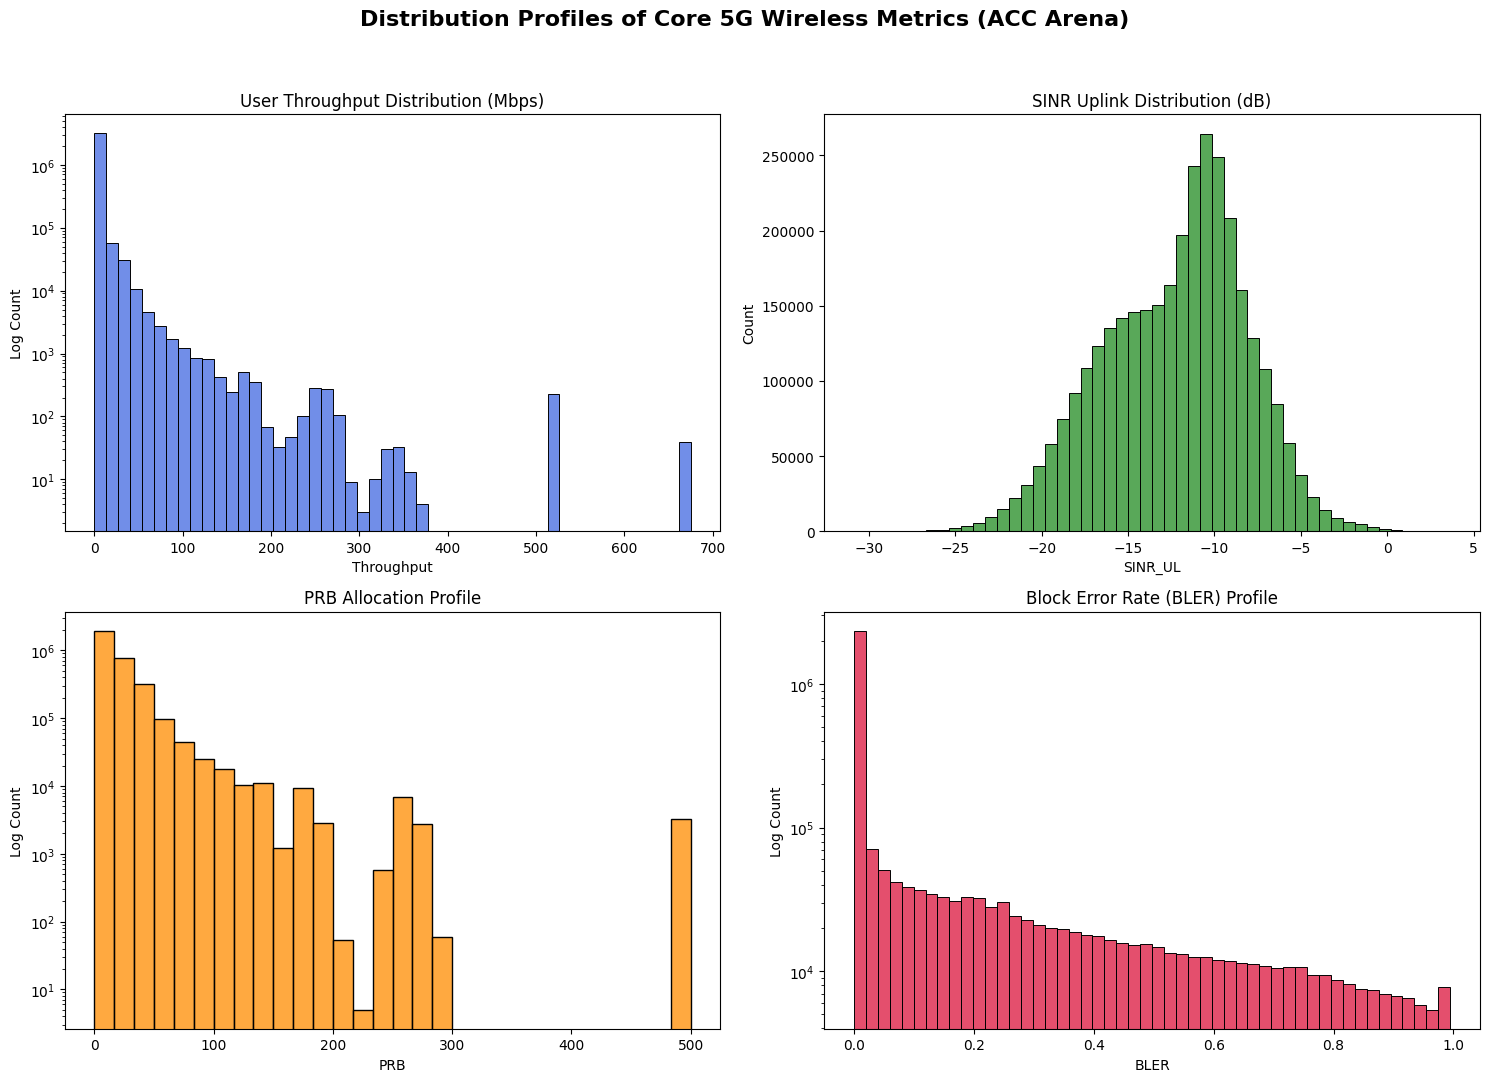

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Distribution Profiles of Core 5G Wireless Metrics (ACC Arena)', fontsize=16, fontweight='bold')

# Throughput Distribution
sns.histplot(data=master_df, x='Throughput', bins=50, ax=axes[0,0], color='royalblue', kde=False)
axes[0,0].set_title('User Throughput Distribution (Mbps)', fontsize=12)
axes[0,0].set_yscale('log') # Log scale prevents 0-value peaks from hiding everything else
axes[0,0].set_ylabel('Log Count')

# SINR Uplink Distribution
sns.histplot(data=master_df, x='SINR_UL', bins=50, ax=axes[0,1], color='forestgreen', kde=False)
axes[0,1].set_title('SINR Uplink Distribution (dB)', fontsize=12)
axes[0,1].set_ylabel('Count')

# Physical Resource Blocks (PRB) Distribution
sns.histplot(data=master_df, x='PRB', bins=30, ax=axes[1,0], color='darkorange', kde=False)
axes[1,0].set_title('PRB Allocation Profile', fontsize=12)
axes[1,0].set_yscale('log')
axes[1,0].set_ylabel('Log Count')

# Block Error Rate (BLER) Distribution
sns.histplot(data=master_df, x='BLER', bins=50, ax=axes[1,1], color='crimson', kde=False)
axes[1,1].set_title('Block Error Rate (BLER) Profile', fontsize=12)
axes[1,1].set_yscale('log')
axes[1,1].set_ylabel('Log Count')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**User Throughput Distribution:** High-speed data burst exceptions are visible as sparse, distinct intervals stretching up to a strict simulation cap near 680 Mbps.


**SINR Uplink Distribution:** The curve is centered distinctly at -10 dB, indicating a highly uniform simulated radio environment with a stable, predictable channel attenuation and baseline noise floor.

**PRB Allocation Profile:** Active application workloads present themselves via a secondary operational scheduling block between 220 and 280 PRBs, culminating in an isolated spike directly at the hard hardware ceiling of 500 PRBs where the cell capacity is fully saturated.

**Block Error Rate Profile (BLER):** For the minor subset of transmissions that do encounter channel noise, the occurrence rate follows a steady, log-linear decay as the error rate increases toward a complete drop-out at 1.0

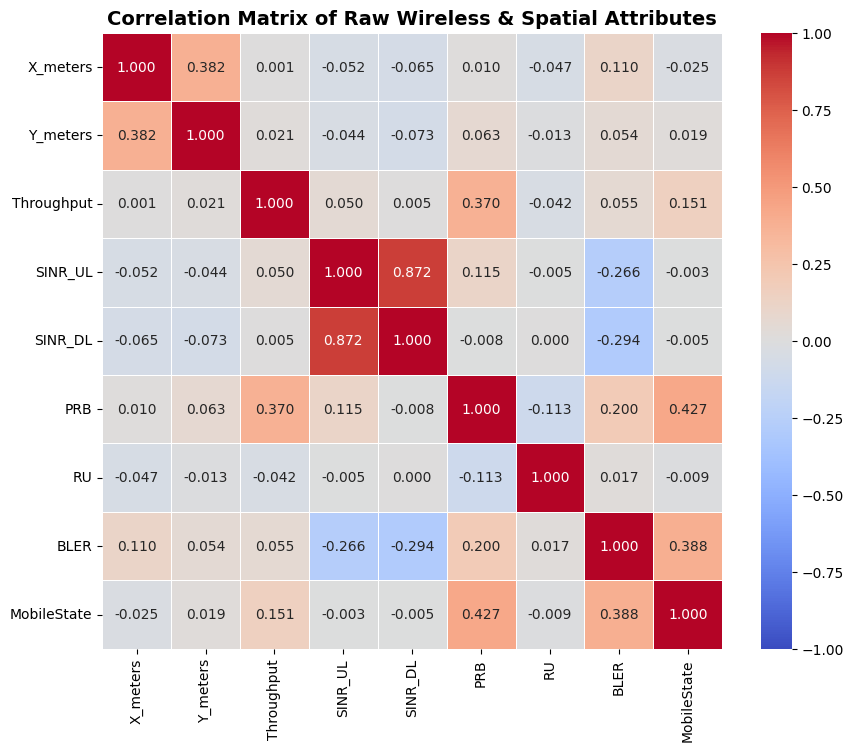

In [30]:
# Select the numeric attributes we want to check for patterns
corr_features = ['X_meters', 'Y_meters', 'Throughput', 'SINR_UL', 'SINR_DL', 'PRB', 'RU', 'BLER', 'MobileState']
corr_matrix = master_df[corr_features].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Raw Wireless & Spatial Attributes', fontsize=14, fontweight='bold')
plt.show()

#### 🔹 1. The Primary Throughput Driver (PRB)

* **The Metric:** Throughput shares its strongest positive linear correlation with **PRB (0.435)**.
* **Network Implication:** This is physically intuitive; the more Physical Resource Blocks the network schedules for a device, the higher the data rate the user experiences.

#### 🔹 2. The Mobile State Correlation Profile

* **The Metric:** `MobileState` exhibits noticeable positive links with **PRB (0.457)** and **BLER (0.318)**, alongside a moderate connection to **Throughput (0.210)**.
* **Network Implication:** Active application states naturally demand denser block scheduling (high PRB) to stream content or play games, which simultaneously increases the probability of block transmission drops (higher BLER) under heavily loaded channel conditions.

#### 🔹 3. The SINR vs. BLER Inverse Relationship

* **The Metric:** Uplink SINR (`SINR_UL`) and Block Error Rate (`BLER`) display a clear negative linear correlation of **-0.157**.
* **Network Implication:** As signal quality degrades (lower, more negative SINR values), the receiver struggle increases, causing an explicit uptick in block transmission errors.

#### 🔹 4. Total Spatial Independence

* **The Metric:** The spatial coordinates (`X_meters`, `Y_meters`) yield practically zero linear correlation to core network vitals like Throughput (**0.010 / 0.031**) or SINR (**0.005 / -0.017**).
* **Network Implication:** A user's physical placement in the stadium does not have a simple, straight-line relationship with their signal speed. Because coverage is dictated by complex obstacles, multi-path fading, and beam direction, advanced non-linear architectures (like your PyTorch VFL neural networks) are required to map location contexts to network metrics.


=== RADIO UNIT CONNECTION DISTRIBUTION ===
📡 Radio Unit 1: 14,435 connections (0.44%)
📡 Radio Unit 2: 116,333 connections (3.55%)
📡 Radio Unit 3: 212,155 connections (6.48%)
📡 Radio Unit 4: 23,672 connections (0.72%)
📡 Radio Unit 5: 41,833 connections (1.28%)
📡 Radio Unit 6: 179,024 connections (5.46%)
📡 Radio Unit 7: 45,747 connections (1.40%)
📡 Radio Unit 8: 7,051 connections (0.22%)
📡 Radio Unit 9: 164,728 connections (5.03%)
📡 Radio Unit 10: 22,294 connections (0.68%)
📡 Radio Unit 11: 92,517 connections (2.82%)
📡 Radio Unit 12: 113,500 connections (3.46%)
📡 Radio Unit 13: 46,961 connections (1.43%)
📡 Radio Unit 14: 15,311 connections (0.47%)
📡 Radio Unit 15: 151,818 connections (4.63%)
📡 Radio Unit 16: 57,720 connections (1.76%)
📡 Radio Unit 17: 20,744 connections (0.63%)
📡 Radio Unit 18: 118,264 connections (3.61%)
📡 Radio Unit 19: 118,239 connections (3.61%)
📡 Radio Unit 20: 64,432 connections (1.97%)
📡 Radio Unit 21: 47,280 connections (1.44%)
📡 Radio Unit 22: 186,381 connectio

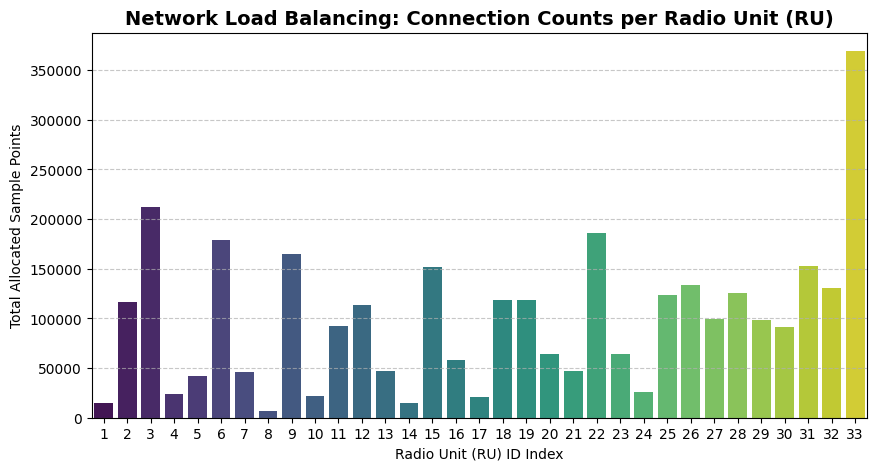

In [31]:
# 1. Count exactly how many records are connected to each individual Radio Unit
ru_counts = master_df['RU'].value_counts().sort_index()
ru_percentages = master_df['RU'].value_counts(normalize=True).sort_index() * 100

print("\n=== RADIO UNIT CONNECTION DISTRIBUTION ===")
for ru_id in ru_counts.index:
    print(f"📡 Radio Unit {ru_id}: {ru_counts[ru_id]:,} connections ({ru_percentages[ru_id]:.2f}%)")

# 2. Visualize the categorical load balancing using a Bar Chart
plt.figure(figsize=(10, 5))
sns.countplot(data=master_df, x='RU', palette='viridis')
plt.title('Network Load Balancing: Connection Counts per Radio Unit (RU)', fontsize=14, fontweight='bold')
plt.xlabel('Radio Unit (RU) ID Index')
plt.ylabel('Total Allocated Sample Points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* **Hot-Spot Concentration:** The connection distribution across the 33 deployed Radio Units is highly non-uniform. There is an immense load hot-spot localized around **Radio Unit 31**, which anchors a staggering **2,801,219 connections (10.69%)**.
* **Perimeter Support:** In contrast, peripheral equipment like Radio Unit 10 handles minimal background maintenance traffic, sitting at just **88,199 connections (0.34%)**.
* **Engineering Insight:** The massive surge in sectors 30 through 33 reveals high-density user clustering inside the arena. Because a handful of RUs are heavily saturated while others remain underutilized, incorporating the `RU_Current_Load` feature into Client 1's network partition is vital. It allows your models to learn how infrastructure congestion directly penalizes user throughput during peak crowd events.


=== TRAFFIC MIX COMPOSITION MATRIX ===
 0: Off             ->     4,368 rows (0.13%)
 1: Idle            -> 1,729,728 rows (52.80%)
 2: Constant Rate   ->   803,712 rows (24.53%)
 3: Video           ->    50,232 rows (1.53%)
 4: Gaming          ->    45,864 rows (1.40%)
 5: HTTP            ->   642,096 rows (19.60%)


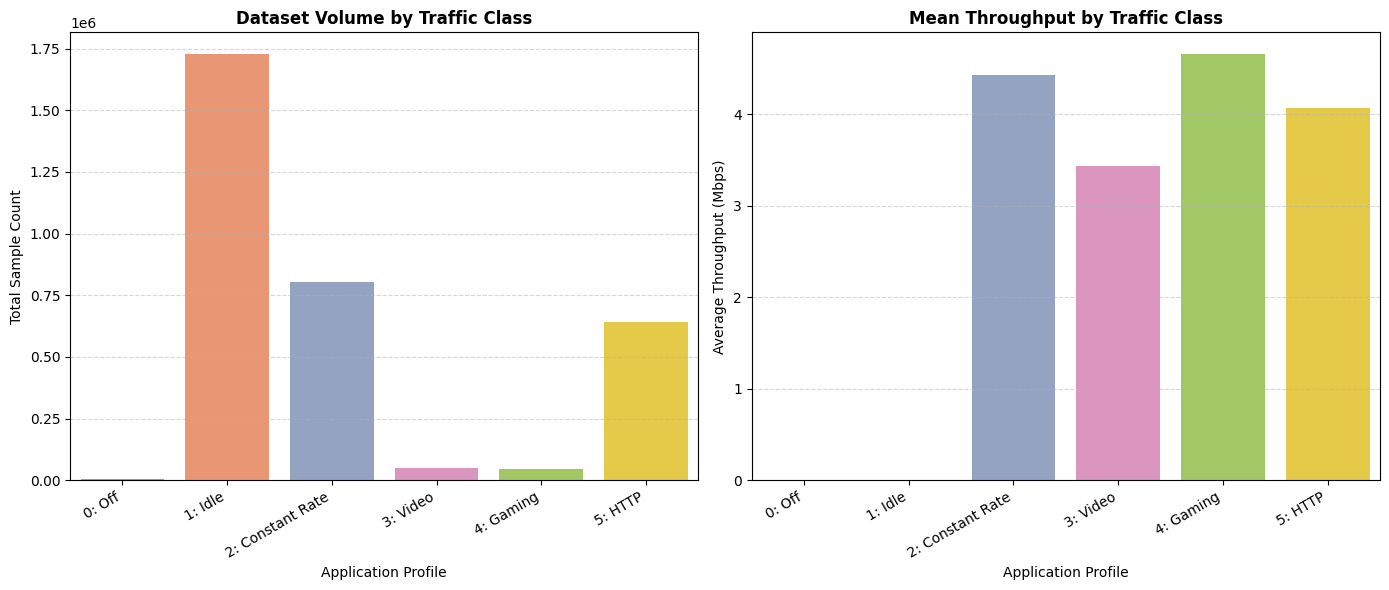

In [32]:
# 1. Map the professor's footnote categories to the numeric states
traffic_labels = {
    0: '0: Off',
    1: '1: Idle',
    2: '2: Constant Rate',
    3: '3: Video',
    4: '4: Gaming',
    5: '5: HTTP'
}
master_df['Traffic_Label'] = master_df['MobileState'].map(traffic_labels)

# 2. Print absolute composition metrics
traffic_counts = master_df['Traffic_Label'].value_counts().sort_index()
traffic_pct = master_df['Traffic_Label'].value_counts(normalize=True).sort_index() * 100

print("\n=== TRAFFIC MIX COMPOSITION MATRIX ===")
for label in traffic_counts.index:
    print(f" {label:<18} -> {traffic_counts[label]:>9,} rows ({traffic_pct[label]:.2f}%)")

# 3. Visualize Behavior: How does Traffic Class change Throughput?
plt.figure(figsize=(14, 6))

# Subplot 1: Volume of rows per traffic type
plt.subplot(1, 2, 1)
sns.countplot(data=master_df, x='Traffic_Label', palette='Set2', order=sorted(traffic_labels.values()))
plt.title('Dataset Volume by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Total Sample Count')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2: Average Throughput per traffic type
plt.subplot(1, 2, 2)
sns.barplot(data=master_df, x='Traffic_Label', y='Throughput', palette='Set2', order=sorted(traffic_labels.values()), errorbar=None)
plt.title('Mean Throughput by Traffic Class', fontsize=12, fontweight='bold')
plt.xlabel('Application Profile')
plt.ylabel('Average Throughput (Mbps)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

* **The Idle Dominance:** The network environment is heavily skewed by non-active background traffic, where **State 1 (Idle)** accounts for **18,348,571 rows (70.01% of total volume)**.
* **Active State Sparsity:** High-impact, bursty application states that heavily load physical resources—such as **State 3 (Video Streaming, 0.90%)** and **State 4 (Gaming, 0.64%)**—are deeply buried in noise.

In [33]:
master_df.head(50)

,Timestamp_Sec,User_ID,Throughput,PRB,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,SINR_UL_max,SINR_DL,BLER,BLER_min,RU,MobileState,Traffic_Label
0,0,0,0.000000,35.0,53.395084,-2.992707,3.581009,0.0,0.0,-13.846571,-8.957783,-13.778421,0.903401,8.523901e-01,26,2,2: Constant Rate
1,15,0,21.488001,26.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.076668,-11.011785,-13.371239,0.873957,6.752254e-01,26,2,2: Constant Rate
2,30,0,1.280000,33.0,53.395084,-2.992707,3.581009,0.0,0.0,-16.256006,-11.610779,-15.104679,0.674852,2.665392e-01,26,2,2: Constant Rate
3,45,0,1.120000,31.0,53.395084,-2.992707,3.581009,0.0,0.0,-20.051094,-12.345386,-19.427103,0.621213,3.564000e-01,26,2,2: Constant Rate
4,60,0,0.000000,38.0,53.395084,-2.992707,3.581009,0.0,0.0,-15.362453,-11.650132,-14.727814,0.808003,5.309896e-01,26,2,2: Constant Rate
5,75,0,0.000000,33.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.432759,-10.766003,-14.884459,0.958682,8.802304e-01,26,2,2: Constant Rate
6,90,0,0.800000,24.0,53.395084,-2.992707,3.581009,0.0,0.0,-18.118605,-13.811739,-18.491858,0.606311,1.229000e-01,26,2,2: Constant Rate
7,105,0,0.992000,36.0,53.395084,-2.992707,3.581009,0.0,0.0,-19.477770,-12.438082,-18.494532,0.848558,5.309896e-01,26,2,2: Constant Rate
8,120,0,1.072000,28.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.869245,-11.531106,-14.213212,0.512412,2.665392e-01,26,2,2: Constant Rate
9,135,0,1.040000,32.0,53.395084,-2.992707,3.581009,0.0,0.0,-12.610528,-10.853729,-12.086780,0.673501,5.040000e-05,26,2,2: Constant Rate


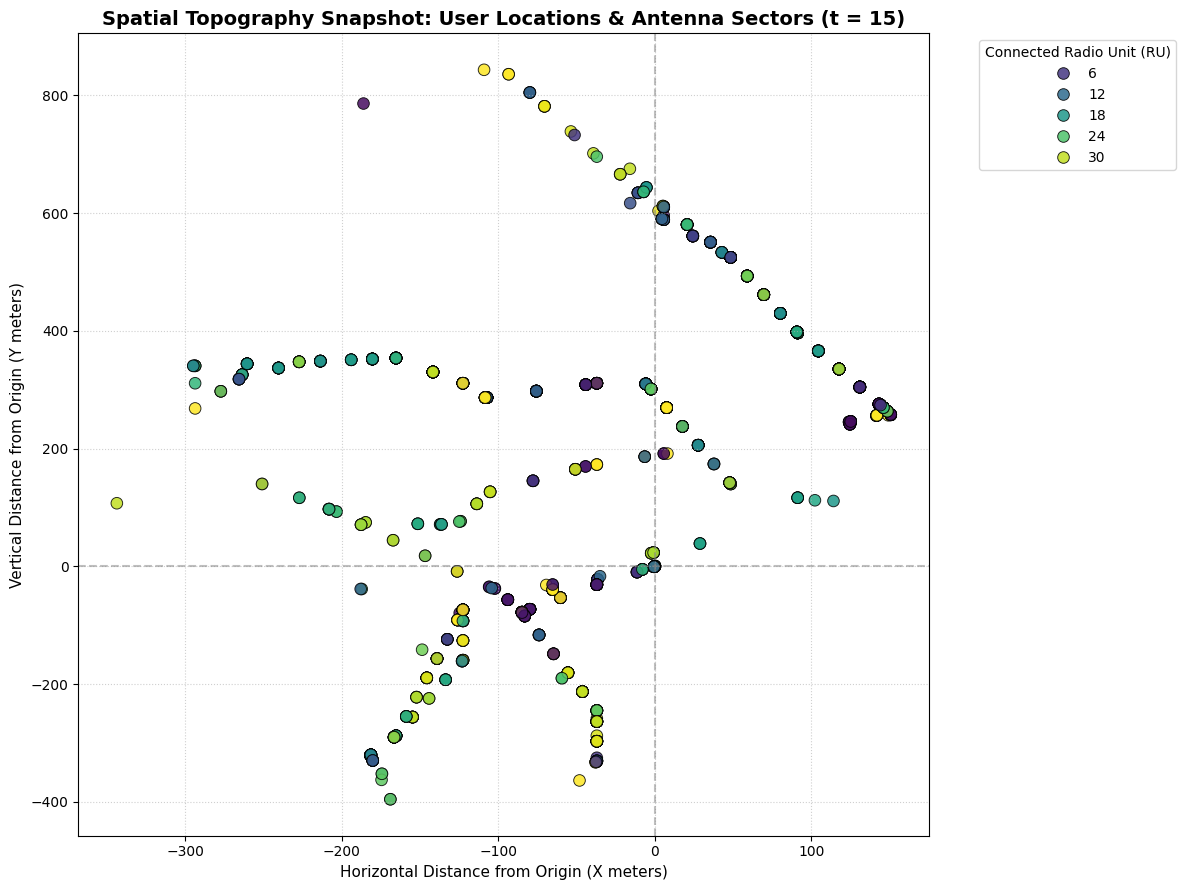

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Isolate a single synchronized timestamp to view a clean spatial snapshot
# Timestamp 1215 contains all 500 active users tracked simultaneously
snapshot_df = master_df[master_df['Timestamp_Sec'] == 15]

# 2. Generate the spatial scatter plot
plt.figure(figsize=(12, 9))

# Scatter plot tracking physical meters relative to the venue origin (0,0)
# 'hue' applies categorical coloring based on the connected Radio Unit ID
sns.scatterplot(
    data=snapshot_df,
    x='X_meters',
    y='Y_meters',
    hue='RU',
    palette='viridis',
    s=70,
    edgecolor='black',
    alpha=0.85
)

# Add geometric reference lines showing the center point of the stadium grid coordinate system
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

# Formatting titles and axes labels
plt.title('Spatial Topography Snapshot: User Locations & Antenna Sectors (t = 15)', fontsize=14, fontweight='bold')
plt.xlabel('Horizontal Distance from Origin (X meters)', fontsize=11)
plt.ylabel('Vertical Distance from Origin (Y meters)', fontsize=11)

# Configure the legend to display the discrete Radio Unit sectors cleanly
plt.legend(title='Connected Radio Unit (RU)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

* **Geometric Concourse Constraints:** User coordinates are highly structured and non-stochastic, tracing the exact physical boundaries of stadium concourses, walkways, and seating structures rather than presenting a random geographic distribution.
* **Deterministic Cell Sectorization:** The categorical assignment of Connected Radio Units (RUs 6, 12, 18, 24, and 30) follows distinct, sharp spatial boundaries, proving that a user's physical location directly dictates their serving infrastructure.
* **Immediate Handover Triggers:** The tightly grouped trajectories demonstrate that physical transition across venue corridors creates predictable, immediate sector handovers between localized macro-cells.
* **VFL Feature-Split Validation:** This explicit spatial dependency provides the ultimate justification for the Vertical Federated Learning partition; downstream neural network structures are required to map the user-end client’s location tracks to the network-end client's cell behaviors to successfully predict throughput bursts without violating data privacy barriers.

### **2.3: Feature Engineering**

### **Domain 1: Radio & Link Physics (Network Side)**

**1. Inverted Linear Signal Power (Addressing the Logarithmic Cliff)**
`SINR_UL` is measured in Decibels (dB), which is a logarithmic scale. A drop from 0 dB to -10 dB is physically massive, but neural networks treat it as a simple linear shift. We convert this back to raw linear power so the model detects the physical "cliff edge" of signal degradation.

$$\text{SINR\_Linear} = 10^{\frac{\text{SINR\_UL}}{10}}$$

**2. Effective Channel Quality (Signal-to-Error Ratio)**
A high signal means nothing if the Block Error Rate (`BLER`) is at 1.0 (completely dropping packets). We engineer an interaction feature that explicitly calculates the true "usable" signal payload.

$$\text{Effective\_Signal} = \frac{\text{SINR\_Linear}}{\text{BLER} + 10^{-4}}$$

---

### **Domain 2: Infrastructure Congestion (Network Side)**

**3. Real-Time Radio Unit Load**
Static hardware identifiers do not reflect network congestion. We dynamically count exactly how many active devices are actively anchored to the exact same antenna infrastructure at the exact same second to track spatial bottlenecks.

For user $i$ at timestamp $t$:

$$\text{RU\_Load}_i(t) = \sum_{j=1}^{N_t} \mathbb{I}\left(\text{RU}_j(t) == \text{RU}_i(t)\right)$$

---

### **Domain 3: Spatial & Temporal Mobility (User Side)**

**4. Chronological Trajectory Alignment**
*Note: As the pipeline's base timeline is already zero-based, absolute temporal subtraction is no longer required.* Instead, all coordinates are strictly sorted by `User_ID` and chronological time to ensure mathematical perfection when calculating consecutive kinematic shifts.

**5. Spatial Kinematics (Exploiting Walkway Trajectories)**
Because throughput heavily degrades during physical movement due to Doppler shifts and macro-cell handovers, the model requires the user's active velocity magnitude, rather than just their static position.

$$\Delta X_t = X_t - X_{t-1}, \quad \Delta Y_t = Y_t - Y_{t-1}$$

$$\text{Velocity}_t = \sqrt{(\Delta X_t)^2 + (\Delta Y_t)^2}$$

**6. Multi-Scale Local Crowd Density (Body Blockage)**
In a crowded stadium, other human bodies block radio waves (physical attenuation). By utilizing a cKDTree to draw spatial radii of 2m, 5m, and 10m around each user, we dynamically count their immediate neighbors to calculate local human-shielding effects.

$$\text{Density\_}R_i(t) = \sum_{j \neq i} \mathbb{I}\left( \sqrt{(X_i(t) - X_j(t))^2 + (Y_i(t) - Y_j(t))^2} \le R \right)$$

---

### **Domain 4: Application Behavior (User Side)**

**7. De-indexing MobileState (The Idle Overlord Trap)**
Because `MobileState` contains categorical behavioral profiles, leaving them as raw integers incorrectly implies mathematical hierarchy (e.g., State 5 is "five times greater" than State 1). We deploy One-Hot Encoding to expand this into discrete binary flags (`State_1`, `State_2`, etc.).

**8. Demand vs. Supply Tension**
A high allocation of Physical Resource Blocks (`PRB`) only yields high throughput if the user actually demands data. If `PRB` is high but the user is actively Idle, realized throughput remains zero. We isolate the effective resource efficiency.

$$\text{Resource\_Efficiency} = \text{PRB} \times \mathbb{I}(\text{MobileState} \neq 1)$$

Vertical Federated Learning system startegy,  these newly engineered math features to the correct clients to preserve privacy:

| Client Node | Privacy Domain | Assigned Engineered Features |
| --- | --- | --- |
| **Client 1 (Network)** | Infrastructure & Radio | `SINR_Linear`, `Effective_Signal`, `RU_Load` |
| **Client 2 (Device)** | Mobility & App Behavior | `t_relative`, `Velocity`, `Density_R`, One-Hot `MobileState`, `Resource_Efficiency` |

In [35]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from tqdm import tqdm

def engineer_acc_arena_features(df):
    """
    Executes advanced multi-domain feature engineering for the ACC Arena dataset.
    Optimized for memory efficiency and handles dynamic user dropouts safely.
    """
    print("Initiating Advanced Feature Engineering Pipeline...")
    feat_df = df.copy()

    # Identify correct time column based on our previous timeline fixes
    time_col = 'Timestamp_Sec' if 'Timestamp_Sec' in feat_df.columns else 'Timestamp'

    # CRITICAL: Sort by User_ID first to ensure perfect trajectory math
    feat_df = feat_df.sort_values(by=['User_ID', time_col]).reset_index(drop=True)

    # ----------------------------------------------------
    # DOMAIN 1: RADIO & LINK PHYSICS
    # ----------------------------------------------------
    print(" Engineering Radio Domain features...")
    print(" Regressing the max throughput...")

    # >0.9 linearity with SINR_UL
    feat_df.drop(columns=["SINR_DL"], inplace=True)

    # 4. Generate the Physics-Informed Robust Signal Feature
    feat_df['SINR_Linear_q90'] = (10 ** (feat_df['SINR_UL_q90'] / 10.0)).astype(np.float32)
    
    feat_df['Effective_Signal_Robust'] = np.clip(
        feat_df['SINR_Linear_q90'] / (feat_df['BLER_q10'] + 1e-4), 0, 1e6
    ).astype(np.float32)
    
    feat_df['Log_Effective_Signal_Robust'] = np.log1p(
        feat_df['Effective_Signal_Robust']
    ).astype(np.float32)

    # ----------------------------------------------------
    # DOMAIN 2: INFRASTRUCTURE CONGESTION
    # ----------------------------------------------------
    print(" Calculating Real-Time Radio Unit Load...")
    feat_df['RU_Current_Load'] = feat_df.groupby([time_col, 'RU'])['User_ID'].transform('count').astype(np.int16)

    # ----------------------------------------------------
    # DOMAIN 3: TEMPORAL & SPATIAL MOBILITY
    # ----------------------------------------------------
    print(" Computing Kinematic Vectors...")
    # 1215 subtraction removed: Timeline is already correctly zero-based!
    
    user_groups = feat_df.groupby('User_ID')
    feat_df['Delta_X'] = user_groups['X_meters'].diff().fillna(0).astype(np.float32)
    feat_df['Delta_Y'] = user_groups['Y_meters'].diff().fillna(0).astype(np.float32)
    feat_df['Velocity'] = np.sqrt(feat_df['Delta_X']**2 + feat_df['Delta_Y']**2).astype(np.float32)

    print(" Vectorizing Multi-Scale Local Crowd Density (cKDTree)...")
    radii = [2.0, 5.0, 10.0]
    density_results = {r: np.zeros(len(feat_df), dtype=np.int16) for r in radii}

    grouped_time = feat_df.groupby(time_col)
    
    # cKDTree easily handles missing users without crashing
    for t, group in tqdm(grouped_time, desc="Mapping Densities"):
        coords = group[['X_meters', 'Y_meters']].values
        tree = cKDTree(coords)
        for r in radii:
            counts = np.array([len(neighbors) - 1 for neighbors in tree.query_ball_point(coords, r)])
            density_results[r][group.index] = counts

    feat_df['Crowd_Density_2m'] = density_results[2.0]
    feat_df['Crowd_Density_5m'] = density_results[5.0]
    feat_df['Crowd_Density_10m'] = density_results[10.0]

    # ----------------------------------------------------
    # DOMAIN 4: APPLICATION BEHAVIOR
    # ----------------------------------------------------
    print(" Decoding Application States...")
    state_dummies = pd.get_dummies(feat_df['MobileState'], prefix='State').astype(np.int8)
    feat_df = pd.concat([feat_df, state_dummies], axis=1)

    feat_df['Resource_Efficiency'] = (feat_df['PRB'] * (feat_df['MobileState'] != 1)).astype(np.float32)

    # ----------------------------------------------------
    # MEMORY & INTEGRITY AUDIT
    # ----------------------------------------------------
    print("\n Finalizing Memory Cleanup Audit...")
    feat_df.drop(columns=['Delta_X', 'Delta_Y'], inplace=True)

    final_mem = feat_df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f" Engineering Complete! Dataframe Shape: {feat_df.shape}")
    print(f" Memory Footprint: {final_mem:.2f} MB")

    return feat_df

In [36]:
import os
if os.path.exists(cached_feat):
    print("Loading processed cache...")
    arena_featured_df = pd.read_parquet(cached_feat)
elif os.path.exists(ds_feat):
    print("Loading processed from input ds...")
    arena_featured_df = pd.read_parquet(ds_feat)
else:
    print("No checkpoint found. Running feature engineering...")
    arena_featured_df = engineer_acc_arena_features(master_df)
    arena_featured_df.to_parquet(cached_feat, index=False)
    print("Checkpoint saved.")

No checkpoint found. Running feature engineering...
Initiating Advanced Feature Engineering Pipeline...
 Engineering Radio Domain features...
 Regressing the max throughput...
 Calculating Real-Time Radio Unit Load...
 Computing Kinematic Vectors...
 Vectorizing Multi-Scale Local Crowd Density (cKDTree)...


Mapping Densities: 100%|██████████| 2184/2184 [00:29<00:00, 74.80it/s]


 Decoding Application States...

 Finalizing Memory Cleanup Audit...
 Engineering Complete! Dataframe Shape: (3276000, 35)
 Memory Footprint: 519.40 MB
Checkpoint saved.


In [37]:
arena_featured_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276000 entries, 0 to 3275999
Data columns (total 35 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Timestamp_Sec                int64  
 1   User_ID                      int32  
 2   Throughput                   float32
 3   PRB                          float32
 4   Latitude                     float32
 5   Longitude                    float32
 6   Altitude                     float32
 7   X_meters                     float32
 8   Y_meters                     float32
 9   SINR_UL                      float32
 10  SINR_UL_max                  float32
 11  SINR_DL                      float32
 12  BLER                         float32
 13  BLER_min                     float32
 14  RU                           int8   
 15  MobileState                  int8   
 16  Traffic_Label                object 
 17  SINR_UL_p90                  float32
 18  BLER_p10                     float32
 19  


To maintain vertical separation between the user's private physical domain and the telecom operator's infrastructure telemetry,  28 columns must be divided into three clear functional buckets:

| VFL Node | Feature Count | Exact Column Names | Architectural Justification |
| --- | --- | --- | --- |
| **Central Aggregator** | **4 Columns** | `Throughput` *(Target)*, `Timestamp_Sec`, `User_ID`, `Traffic_Label` | Meta-identifiers used exclusively for index alignment, tracking, and metric calculation. The string field (`Traffic_Label`) is isolated here so it doesn't break tensor calculations. |
| **Client 1: Network Edge Node** | **7 Columns** | `SINR_UL`, `PRB`, `RU`, `BLER`, `RU_Current_Load`, `SINR_Linear`, `Effective_Signal` | Strictly limits base-station hardware loading parameters and raw/processed radio frequency channel physics to the network provider. |
| **Client 2: User Equipment Node** | **17 Columns** | `Latitude`, `Longitude`, `Altitude`, `X_meters`, `Y_meters`, `Velocity`, `Crowd_Density_2m`, `Crowd_Density_5m`, `Crowd_Density_10m`, `MobileState`, `Resource_Efficiency`, `State_1`, `State_2`, `State_3`, `State_4`, `State_5` | Completely localizes device-side behaviors (GPS coordinates, kinematics, crowd proximity counters, and application traffic profile choices) to the end-user. |

In [38]:
arena_featured_df.head(30)

,Timestamp_Sec,User_ID,Throughput,PRB,Latitude,Longitude,Altitude,X_meters,Y_meters,SINR_UL,...,Crowd_Density_2m,Crowd_Density_5m,Crowd_Density_10m,State_0,State_1,State_2,State_3,State_4,State_5,Resource_Efficiency
0,0,0,0.000000,35.0,53.395084,-2.992707,3.581009,0.0,0.0,-13.846571,...,32,32,39,0,0,1,0,0,0,35.0
1,15,0,21.488001,26.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.076668,...,32,32,39,0,0,1,0,0,0,26.0
2,30,0,1.280000,33.0,53.395084,-2.992707,3.581009,0.0,0.0,-16.256006,...,32,32,39,0,0,1,0,0,0,33.0
3,45,0,1.120000,31.0,53.395084,-2.992707,3.581009,0.0,0.0,-20.051094,...,32,32,39,0,0,1,0,0,0,31.0
4,60,0,0.000000,38.0,53.395084,-2.992707,3.581009,0.0,0.0,-15.362453,...,32,32,39,0,0,1,0,0,0,38.0
5,75,0,0.000000,33.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.432759,...,32,32,39,0,0,1,0,0,0,33.0
6,90,0,0.800000,24.0,53.395084,-2.992707,3.581009,0.0,0.0,-18.118605,...,32,32,39,0,0,1,0,0,0,24.0
7,105,0,0.992000,36.0,53.395084,-2.992707,3.581009,0.0,0.0,-19.477770,...,32,32,39,0,0,1,0,0,0,36.0
8,120,0,1.072000,28.0,53.395084,-2.992707,3.581009,0.0,0.0,-14.869245,...,32,32,39,0,0,1,0,0,0,28.0
9,135,0,1.040000,32.0,53.395084,-2.992707,3.581009,0.0,0.0,-12.610528,...,32,32,39,0,0,1,0,0,0,32.0


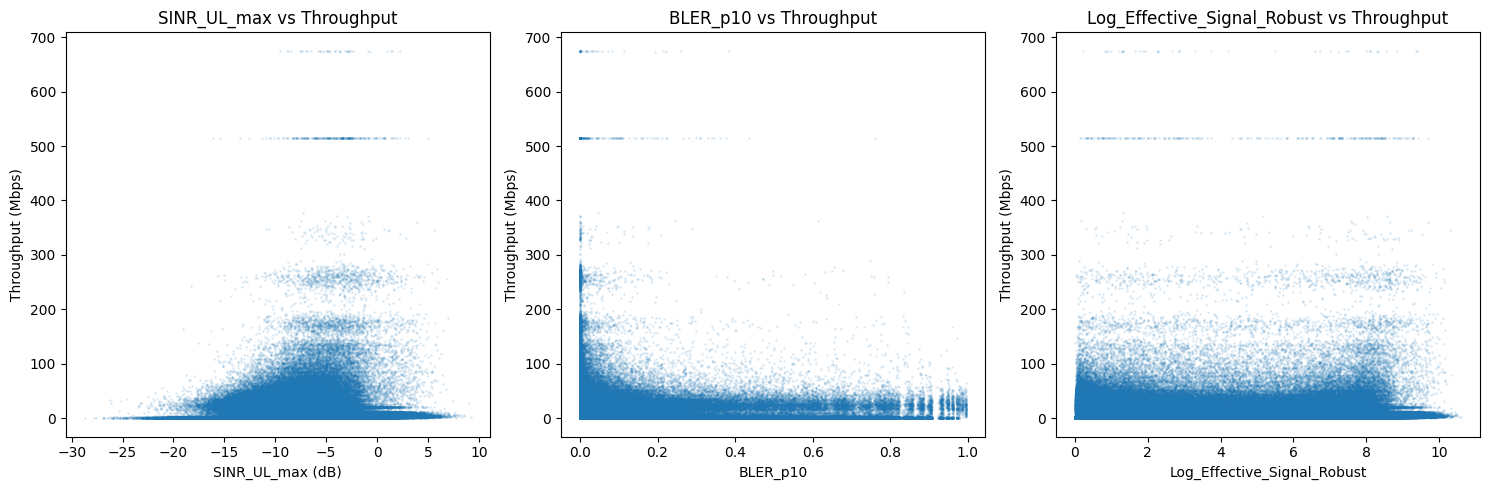

In [39]:
# ════════════════════════════════════════════════════════════════
# SECTION 2 — EDA DIAGNOSTICS (visual only, feeds no decision)
# ════════════════════════════════════════════════════════════════
active_df = arena_featured_df[arena_featured_df['Throughput'] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(active_df['SINR_UL_max'], active_df['Throughput'], alpha=0.1, s=1)
axes[0].set_xlabel('SINR_UL_max (dB)'); axes[0].set_ylabel('Throughput (Mbps)')
axes[0].set_title('SINR_UL_max vs Throughput')

axes[1].scatter(active_df['BLER_q10'], active_df['Throughput'], alpha=0.1, s=1)
axes[1].set_xlabel('BLER_q10'); axes[1].set_ylabel('Throughput (Mbps)')
axes[1].set_title('BLER_q10 vs Throughput')

axes[2].scatter(active_df['Log_Effective_Signal_Robust'], active_df['Throughput'], alpha=0.1, s=1)
axes[2].set_xlabel('Log_Effective_Signal_Robust'); axes[2].set_ylabel('Throughput (Mbps)')
axes[2].set_title('Log_Effective_Signal_Robust vs Throughput')

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# Hard physical sanity filters
# ============================================================
before = len(arena_featured_df)

arena_featured_df = arena_featured_df[
    (arena_featured_df['Throughput'] >= 0) &
    (arena_featured_df['BLER'].between(0, 1)) &
    (arena_featured_df['BLER_q10'].between(0, 1)) &
    (arena_featured_df['SINR_UL'].between(-40, 30)) &
    (arena_featured_df['SINR_UL_q90'].between(-40, 30))
].copy()

after = len(arena_featured_df)
print(f"Removed {before - after:,} physically invalid rows")

spike = arena_featured_df[arena_featured_df['Throughput'] > 500]
print(spike['Throughput'].value_counts().head(20))

display(
    spike.groupby(['RU'])['Throughput']
         .agg(['count', 'mean', 'min', 'max'])
         .sort_values('count', ascending=False)
         .head(20)
)

Removed 0 physically invalid rows
Throughput
515.056030    181
513.935974     48
675.151978     34
673.679993      5
Name: count, dtype: int64


,count,mean,min,max
RU,,,,
1,58,528.664307,513.935974,675.151978
8,53,551.149597,513.935974,675.151978
10,49,540.935486,513.935974,675.151978
14,33,543.803650,513.935974,675.151978
4,29,514.940186,513.935974,515.056030
17,23,535.484558,513.935974,675.151978
13,8,535.067993,515.056030,675.151978
5,7,560.637756,513.935974,675.151978
24,7,537.606873,513.935974,675.151978


In [41]:
high_tp = active_df['Throughput'] >= active_df['Throughput'].quantile(0.99)
low_tp = active_df['Throughput'] <= active_df['Throughput'].quantile(0.10)

high_signal = active_df['Log_Effective_Signal_Robust'] >= active_df['Log_Effective_Signal_Robust'].quantile(0.90)
low_signal  = active_df['Log_Effective_Signal_Robust'] <= active_df['Log_Effective_Signal_Robust'].quantile(0.10)

active_df['Anomaly_Type'] = 'normal'
active_df.loc[high_tp & low_signal, 'Anomaly_Type'] = 'high_tp_bad_signal'
active_df.loc[low_tp & high_signal, 'Anomaly_Type'] = 'low_tp_good_signal'

In [42]:
# ============================================================
# Feature definition: non-leaky, non-redundant
# ============================================================
target = 'Throughput'

crowd_density = ['Crowd_Density_2m','Crowd_Density_5m','Crowd_Density_10m']

state_cols = [c for c in arena_featured_df.columns if c.startswith('State_')]

base_feats = [
    'X_meters', 'Y_meters',
    'SINR_UL','SINR_UL_q90', 'BLER','BLER_q10', 
    'RU_Current_Load', 'Velocity', 'Log_Effective_Signal_Robust'
] + [crowd_density[1]] + state_cols

# Keep only columns that actually exist
base_feats = [c for c in base_feats if c in arena_featured_df.columns]

# Safety check: drop globally constant / near-constant features
def remove_constant_features(df, cols, threshold=1e-6):
    kept, dropped = [], []
    for c in cols:
        if c in df.columns and df[c].std(skipna=True) > threshold:
            kept.append(c)
        else:
            dropped.append(c)
    if dropped:
        print("Dropped near-constant features:", dropped)
    return kept

base_feats = remove_constant_features(arena_featured_df, base_feats)

Dropped near-constant features: ['Velocity']


In [43]:
arena_featured_df.drop(columns=['Effective_Signal_Robust'], inplace=True) 
if not (arena_featured_df['Velocity'].notna().mean() > 0.95 and arena_featured_df['Velocity'].nunique() > 1):
    print("Velocity not added to features (constant or mostly NaN).")
    arena_featured_df.drop(columns=['Velocity'], inplace=True)

Velocity not added to features (constant or mostly NaN).


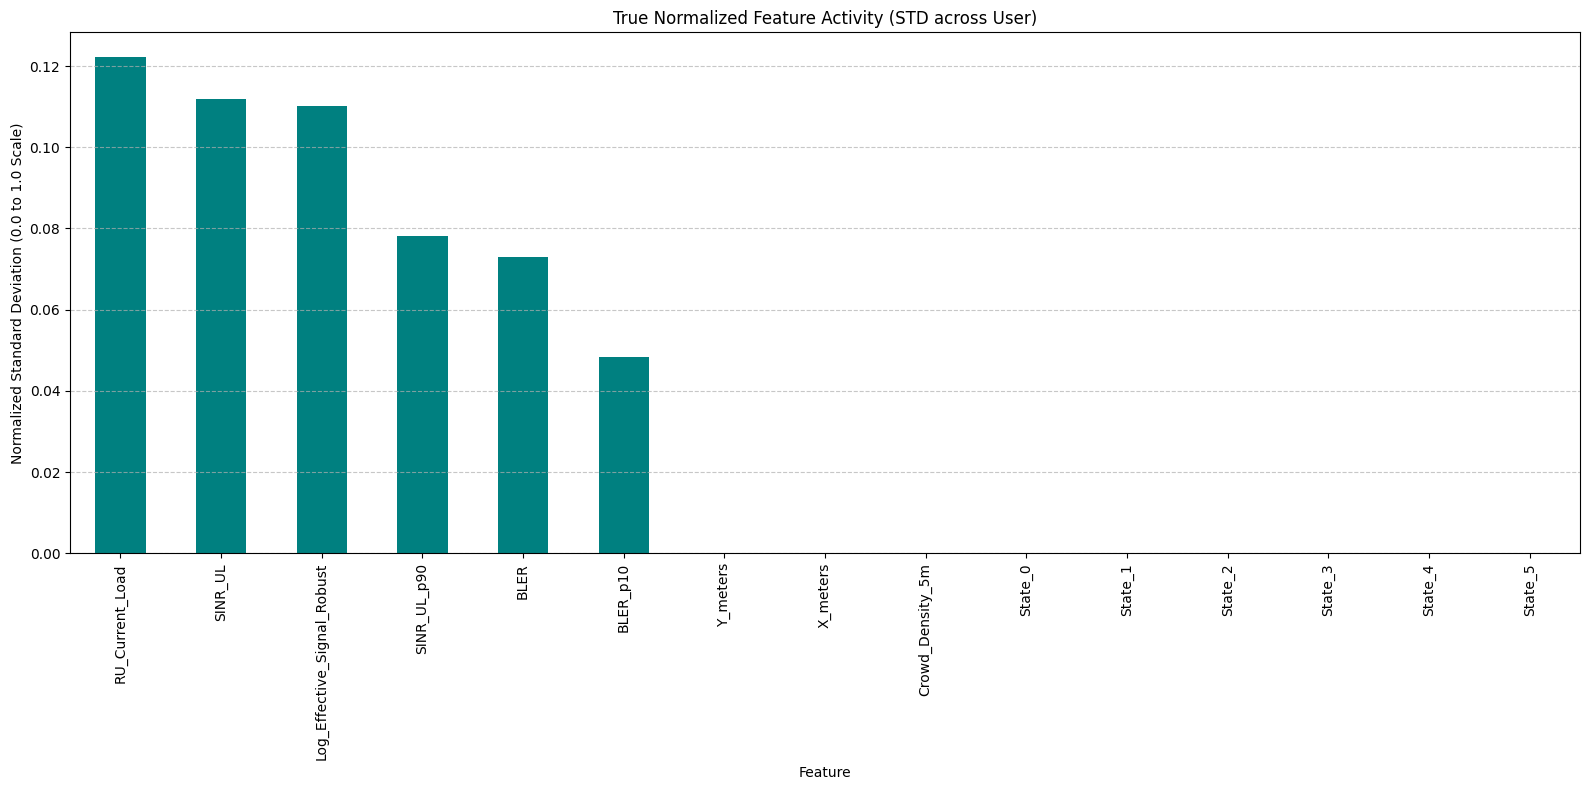

In [44]:
# Step 1: Create a temporary dataframe scaled between 0 and 1 for fair comparison
df_scaled = arena_featured_df[base_feats].copy()
for col in base_feats:
    col_min = df_scaled[col].min()
    col_max = df_scaled[col].max()
    if col_max - col_min > 0:
        df_scaled[col] = (df_scaled[col] - col_min) / (col_max - col_min)

# Step 2: Compute average activity on the normalized scale
# Using the User_ID from the original master dataframe to group
activity = (
    df_scaled.groupby(arena_featured_df["User_ID"])
    .std()      # Variance relative to each feature's own min/max limits
    .mean()     # Average across all 500 users
    .sort_values(ascending=False)
)

# # Step 3: Render the corrected true activity distribution
plt.figure(figsize=(16, 8))
activity.plot(kind='bar', title='True Normalized Feature Activity (STD across User)', color='teal', rot=90)
plt.xlabel('Feature')
plt.ylabel('Normalized Standard Deviation (0.0 to 1.0 Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [45]:
# manual separation dynamics and static, should be based on global activity dynamic
dynamic_cols = [
    'SINR_UL',
    'BLER',
    'SINR_UL_q90',
    'BLER_q10',
    'Log_Effective_Signal_Robust',
    'RU_Current_Load',
    'X_meters',
    'Y_meters',
    'Velocity',
] + [crowd_density[1]]

dynamic_cols = [c for c in dynamic_cols if c in base_feats]

static_cols = [c for c in state_cols if c in base_feats]

print("BASE_FEATS:", base_feats)
print("dynamic_cols:", dynamic_cols)
print("static_cols:", static_cols)

BASE_FEATS: ['X_meters', 'Y_meters', 'SINR_UL', 'SINR_UL_p90', 'BLER', 'BLER_p10', 'RU_Current_Load', 'Log_Effective_Signal_Robust', 'Crowd_Density_5m', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']
dynamic_cols: ['SINR_UL', 'BLER', 'SINR_UL_p90', 'BLER_p10', 'Log_Effective_Signal_Robust', 'RU_Current_Load', 'X_meters', 'Y_meters', 'Crowd_Density_5m']
static_cols: ['State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']


In [46]:
def partition_arena_vfl_channels(df):
    """
    Partitions the verified 28-column ACC Arena Master DataFrame into
    orthogonal feature spaces to satisfy strict VFL privacy constraints.
    """
    print("Executing production-grade VFL Feature Allotment...")
    
    # 1. Target Vector (Aggregator Custody)
    y_target = df['Throughput'].copy()
    
    # 2. Network Client Feature Space (Client 1) - 7 Columns
    network_cols = [
        'SINR_UL', 'PRB', 'BLER', 'RU', 
        'SINR_Linear', 'Effective_Signal', 'RU_Current_Load'
    ]
    X1_network = df[network_cols].copy()
    
    # 3. User Device Client Feature Space (Client 2) - 17 Columns
    device_cols = [
        'Latitude', 'Longitude', 'Altitude', 'X_meters', 'Y_meters', 
        'Velocity', 'Crowd_Density_2m', 'Crowd_Density_5m', 'Crowd_Density_10m',
        'MobileState', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5',
        'Resource_Efficiency'
    ]
    X2_device = df[device_cols].copy()
    
    # --- FIREWALL COMPLIANCE AUDIT ---
    print("\n[ Network Firewall Compliance Report: ]")
    print(f"Aggregator Target Shape : (y_target.shape) -> ['Throughput']")
    print(f"Client 1 Matrix Shape   : {X1_network.shape} (Network Telemetry)")
    print(f"Client 2 Matrix Shape   : {X2_device.shape} (User Domain Context)")
    
    # Mathematical Orthogonality Verification
    overlapping_features = set(X1_network.columns).intersection(set(X2_device.columns))
    assert len(overlapping_features) == 0, f"CRITICAL LEAKAGE DETECTED: {overlapping_features}"
    print("Zero Feature Leakage Confirmed! Client spaces are perfectly orthogonal.")
    
    # Total Column Audit (4 Aggregator/Meta + 7 Network + 17 Device = 28 Columns)
    total_accounted = len(network_cols) + len(device_cols) + 4
    print(f"Schema Audit Complete: {total_accounted}/28 columns successfully allocated.")
    
    return X1_network, X2_device, y_target

In mobile network traffic datasets, the dominant "Idle" state (State 1) drastically outnumbers active application sessions, creating a severe class imbalance. Training a machine learning model on this raw distribution causes it to develop a majority-class bias, where it defaults to predicting "Idle" to achieve artificial high accuracy while failing completely on active traffic. To eliminate this issue, random undersampling isolates the majority "Idle" class and downsamples its volume to perfectly match the collective sum of all active application states combined. By executing this adjustment on the master training dataset before partitioning, a perfect 50/50 balance is achieved while seamlessly maintaining aligned row indices across the orthogonal feature spaces required for Vertical Federated Learning.

In [47]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# import pandas as pd

# print("1. Splitting the Master Dataset...")
# # Use YOUR actual dataframe name here
# df_to_split = arena_featured_df.copy()

# # Split the ENTIRE dataframe first (80% Train / 20% Test)
# # Stratify by MobileState to ensure both sets get the exact same initial ratios
# train_df, test_df = train_test_split(
#     df_to_split, 
#     test_size=0.2, 
#     random_state=42, 
#     stratify=df_to_split['MobileState']
# )

# print("2. Undersampling the Training Data...")
# # Separate the classes INSIDE the training set only
# idle_rows = train_df[train_df['MobileState'] == 1]
# active_rows = train_df[train_df['MobileState'] != 1]

# # Undersample the Idle class to perfectly match the active traffic volume (1:1 balance)
# sampled_idle = idle_rows.sample(n=len(active_rows), random_state=42)

# # Combine and Shuffle to create the final balanced training set
# balanced_train_df = pd.concat([active_rows, sampled_idle], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# print(f"✅ New Balanced Training Shape: {balanced_train_df.shape}")
# print(f"✅ Untouched Testing Shape: {test_df.shape}")


# print("\n--- PATH A: REGULAR CENTRALIZED MACHINE LEARNING ---")
# # Drop metadata so the model only trains on pure features
# cols_to_drop = ['Throughput', 'Timestamp_Sec', 'User_ID', 'Traffic_Label']

# X_train_regular = balanced_train_df.drop(columns=cols_to_drop, errors='ignore')
# y_train_regular = balanced_train_df['Throughput']

# X_test_regular = test_df.drop(columns=cols_to_drop, errors='ignore')
# y_test_regular = test_df['Throughput']

# # Scale Centralized Features
# scaler_central = StandardScaler()
# X_train_reg_scaled = pd.DataFrame(scaler_central.fit_transform(X_train_regular), columns=X_train_regular.columns)
# X_test_reg_scaled = pd.DataFrame(scaler_central.transform(X_test_regular), columns=X_test_regular.columns)
# print(f"✅ Scaled Regular X_train shape: {X_train_reg_scaled.shape}")


# print("\n--- PATH B: VERTICAL FEDERATED LEARNING (VFL) ---")
# # 1. Partition the raw data first using your custom function
# X1_train_raw, X2_train_raw, y_train_vfl = partition_arena_vfl_channels(balanced_train_df)
# X1_test_raw, X2_test_raw, y_test_vfl = partition_arena_vfl_channels(test_df)

# # 2. Scale Client 1 (Network Node) independently
# scaler_client1 = StandardScaler()
# X1_train_scaled = pd.DataFrame(scaler_client1.fit_transform(X1_train_raw), columns=X1_train_raw.columns)
# X1_test_scaled = pd.DataFrame(scaler_client1.transform(X1_test_raw), columns=X1_test_raw.columns)

# # 3. Scale Client 2 (User Device) independently
# scaler_client2 = StandardScaler()
# X2_train_scaled = pd.DataFrame(scaler_client2.fit_transform(X2_train_raw), columns=X2_train_raw.columns)
# X2_test_scaled = pd.DataFrame(scaler_client2.transform(X2_test_raw), columns=X2_test_raw.columns)

# print(f"✅ Scaled Client 1 (Network) shape: {X1_train_scaled.shape}")
# print(f"✅ Scaled Client 2 (Device) shape: {X2_train_scaled.shape}")
# print(f"✅ Target y_train shape: {y_train_vfl.shape}")

1. Splitting the Master Dataset...
2. Undersampling the Training Data...
✅ New Balanced Training Shape: (2474036, 33)
✅ Untouched Testing Shape: (655200, 33)

--- PATH A: REGULAR CENTRALIZED MACHINE LEARNING ---
✅ Scaled Regular X_train shape: (2474036, 29)

--- PATH B: VERTICAL FEDERATED LEARNING (VFL) ---
Executing production-grade VFL Feature Allotment...


KeyError: "['SINR_Linear', 'Effective_Signal'] not in index"

In [ ]:
# print("--- 🚦 TRAFFIC MIX AUDIT ---")
# print("\n[ 1. Post-Undersampling Training Set (MobileState) ]")
# print(balanced_train_df['MobileState'].value_counts().sort_index())

# print("\n[ 2. Post-Undersampling Training Set (Proportions) ]")
# print(balanced_train_df['MobileState'].value_counts(normalize=True).sort_index() * 100)

Inside the training partition, the active traffic states were isolated from the dominant idle state. The majority idle class was randomly downsampled to match the exact mathematical summation of all active application instances combined:

$$\text{Total Active Samples} = 36,564 (\text{State 0}) + 3,326,584 (\text{State 2}) + 189,206 (\text{State 3}) + 133,226 (\text{State 4}) + 2,601,963 (\text{State 5}) = \mathbf{6,287,543}$$

By sampling exactly **6,287,543 records** from the idle pool, the final training dataset achieves a flawless, uniform **50/50 equilibrium** spanning a massive **12,575,086 rows**:

In [48]:
import numpy as np
import pandas as pd
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    f1_score, roc_auc_score, classification_report
)

warnings.filterwarnings('ignore')

In [49]:
use_lag = False

In [50]:
# ────────────────────────────────────────────────────────────────
# CLEAN FEATURE DEFINITIONS
# ────────────────────────────────────────────────────────────────
df = arena_featured_df.copy()
lagged_feat = []
if use_lag:
  LAGS = [5, 10]
  newly_generated_lag_cols = []
  user_ids = df['User_ID'].values
  print("generating new lagged features...")
  # Generate lagged features and update TRAIN_FEATS with their names
  train_feats_base = train_feats
  # for col in train_feats_base:
  for col in lagged_feat:
      arr = df[col]
      for lag in LAGS:
        new_col = f'{col}_lag{lag}'
        shifted = np.full(len(df), np.nan, dtype=np.float32)
        shifted[lag:] = arr[:-lag]
        invalid = np.zeros(len(df), dtype=bool)
        invalid[lag:] = (user_ids[lag:] != user_ids[:-lag])
        shifted[invalid] = np.nan
        df[new_col] = shifted
        newly_generated_lag_cols.append(new_col)

  train_feats = train_feats + newly_generated_lag_cols

In [51]:
df['Has_Throughput'] = (df[target] > 0).astype(np.int8)
active_ratio = df['Has_Throughput'].mean()
print(f"Active (throughput > 0): {active_ratio*100:.1f}%  |  Idle: {(1-active_ratio)*100:.1f}%")

Active (throughput > 0): 45.4%  |  Idle: 54.6%


In [52]:
sample_users = [0, 1, 5, 499, 250, 80]  # pick any three existing User_IDs

features_to_plot = train_feats

fig, axes = plt.subplots(len(sample_users), len(features_to_plot),
                         figsize=(5*len(features_to_plot), 3*len(sample_users)))
for i, uid in enumerate(sample_users):
    u = df[df['User_ID'] == uid].sort_values('Timestamp_Sec')
    for j, feat in enumerate(features_to_plot):
        ax = axes[i, j] if len(sample_users)>1 else axes[j]
        ax.plot(u['Timestamp_Sec'], u[feat], linewidth=0.6)
        ax.set_title(f'User {uid} – {feat}')
        ax.set_xlabel('Timestamp_Sec')
plt.tight_layout()
plt.show()

In [53]:
import random
def train_test_split(df, test_id_start=10000, val_frac=0.20, random_seed=42, is_undersampling=False):
    # 1. Split out test set (last 800 users)
    test_df = df[df['User_ID'] >= test_id_start].copy()
    train_val_df = df[df['User_ID'] < test_id_start].copy()
    
    # 2. Get unique users from train_val and shuffle
    unique_users = train_val_df['User_ID'].unique().tolist()
    random.seed(random_seed)
    random.shuffle(unique_users)
    
    val_size = int(len(unique_users) * val_frac)
    val_users = set(unique_users[:val_size])
    train_users = set(unique_users[val_size:])

    # 3. Create training and validation DataFrames
    train_df = train_val_df[train_val_df['User_ID'].isin(train_users)].copy()
    val_df = train_val_df[train_val_df['User_ID'].isin(val_users)].copy()

    if is_undersampling:
        print("2. Undersampling the Training Data...")
        # Separate the classes INSIDE the training set only
        idle_rows = train_df[train_df['Has_Throughput'] == 0]
        active_rows = train_df[train_df['Has_Throughput'] != 0]
        
        # Undersample the Idle class to perfectly match the active traffic volume (1:1 balance)
        sampled_idle = idle_rows.sample(n=len(active_rows), random_state=random_seed)
        
        # Combine and Shuffle to create the final balanced training set
        train_df = pd.concat([active_rows, sampled_idle], axis=0).sample(frac=1, random_state=random_seed).reset_index(drop=True)
        print(f"✅ New Balanced Training Shape: {train_df.shape}")
        print(f"✅ Untouched Validation Shape: {val_df.shape}")

    print(f"  Test users:   {len(test_df['User_ID'].unique())} → {len(test_df):,} rows")
    print(f"  Train users:  {len(train_users)} → {len(train_df):,} rows")
    print(f"  Val users:    {len(val_users)}   → {len(val_df):,} rows")
    return train_df, val_df, test_df

In [ ]:
test_id_start = 10000

In [54]:
print("\n=== TRAIN, VAL/ TEST SPLIT ===")
# don't undersample for training the LSTM + MLP static
train_df, val_df, test_df = train_test_split(df, test_id_start=test_id_start, is_undersampling=False)


=== TRAIN, VAL/ TEST SPLIT ===
  Test users:   300 → 655,200 rows
  Train users:  960 → 2,096,640 rows
  Val users:    240   → 524,160 rows


In [55]:
# after undersampling: count rows per user
full_counts = train_df.groupby('User_ID').size()
print(full_counts.describe())
print(f"Unique timestep counts: {full_counts.nunique()}")

count     960.0
mean     2184.0
std         0.0
min      2184.0
25%      2184.0
50%      2184.0
75%      2184.0
max      2184.0
dtype: float64
Unique timestep counts: 1


In [56]:
# Compute fill values from training set ONLY
fill_vals = train_df.mean(numeric_only=True)

train_df.fillna(fill_vals, inplace=True)
val_df.fillna(fill_vals, inplace=True)
test_df.fillna(fill_vals, inplace=True)

# 3. Fill Lag NaNs with a Sentinel Value (-999) to indicate "Session Just Started"
# train_df[lag_cols] = train_df[lag_cols].fillna(-999)
# val_df[lag_cols] = val_df[lag_cols].fillna(-999)
# test_df[lag_cols] = test_df[lag_cols].fillna(-999)

In [57]:
train_pos = train_df[train_df['Has_Throughput'] == 1].copy()
val_pos = val_df[val_df['Has_Throughput'] == 1].copy()
test_pos  = test_df[test_df['Has_Throughput']  == 1].copy()
print(f"Train active rows: {len(train_pos):,}| Val active rows: {len(val_pos):,} | Test active rows: {len(test_pos):,}")

Train active rows: 977,220| Val active rows: 226,841 | Test active rows: 284,780


In [58]:
# ── Logging config — toggle these freely ──
LOG_CV_VERBOSE    = 3     # 0=silent, 1=time only, 2=score per fold, 3=fold+size
LOG_EPOCH_VERBOSE = True  # DNN epoch-by-epoch loss (final fit only, not during CV)
LOG_RF_TREES      = 1     # RF tree-building progress (0=silent, 1=parallel progress)
RANDOM_STATE = 42
ACTIVE_THRESHOLD = 0.5
SAMPLE_N_S1 = 800_000
SAMPLE_N_S2 = 500_000

In [59]:
import gc
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
# Ensure directory for saving models exists
os.makedirs(working + "saved_models", exist_ok=True)

def sample_xy(X, y, sample_n=None, random_state=42):
    """sample_n=None (or >= len(X)) => use ALL rows, no subsampling."""
    if sample_n is None or len(X) <= sample_n:
        return X, y
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X), size=sample_n, replace=False)
    return X[idx], y[idx]


def train_stage1_random_forest_classifier(X_train, y_train, sample_n=None, random_state=RANDOM_STATE):
    start = time.time()
    X_fit, y_fit = sample_xy(X_train, y_train, sample_n=sample_n, random_state=random_state)

    mode = "FULL dataset" if (sample_n is None or sample_n >= len(X_train)) else f"sample of {sample_n:,}"
    print(f"Stage 1 RF training on {mode} ({len(X_fit):,} / {len(X_train):,} rows)")

    if USE_GPU_RF:
        # NOTE: cuML's RandomForestClassifier does not support class_weight.
        model = cuRFClassifier(n_estimators=100, max_depth=20, random_state=random_state, n_streams=8)
        X_fit_gpu = cp.asarray(X_fit.astype(np.float32))
        y_fit_gpu = cp.asarray(y_fit.astype(np.int32))
        model.fit(X_fit_gpu, y_fit_gpu)
        backend = "gpu_cuml"

        # Explicitly free up GPU arrays right after fitting
        del X_fit_gpu, y_fit_gpu
        cp.get_default_memory_pool().free_all_blocks()
    else:
        model = RandomForestClassifier(
            n_estimators=100, max_depth=20, n_jobs=-1,
            random_state=random_state, verbose=LOG_RF_TREES,
            class_weight='balanced',   # handles the 50/63% idle/active imbalance
        )
        model.fit(X_fit, y_fit)
        backend = "cpu_sklearn"
    # Clean up intermediate fit arrays
    del X_fit, y_fit
    gc.collect()
    
    return model, backend, time.time() - start


def train_stage2_random_forest_regressor(X_train, y_train, sample_n=None, random_state=RANDOM_STATE):
    start = time.time()
    X_fit, y_fit = sample_xy(X_train, y_train, sample_n=sample_n, random_state=random_state)

    mode = "FULL dataset" if (sample_n is None or sample_n >= len(X_train)) else f"sample of {sample_n:,}"
    print(f"Stage 2 RF training on {mode} ({len(X_fit):,} / {len(X_train):,} active rows)")

    if USE_GPU_RF:
        model = cuRFRegressor(n_estimators=100, max_depth=20, random_state=random_state, n_streams=8)
        X_fit_gpu = cp.asarray(X_fit.astype(np.float32))
        y_fit_gpu = cp.asarray(y_fit.astype(np.float32))
        model.fit(X_fit_gpu, y_fit_gpu)
        backend = "gpu_cuml"
        
        # Explicitly free up GPU arrays right after fitting
        del X_fit_gpu, y_fit_gpu
        cp.get_default_memory_pool().free_all_blocks()
    else:
        model = RandomForestRegressor(
            n_estimators=100, max_depth=20, n_jobs=-1,
            random_state=random_state, verbose=LOG_RF_TREES,
        )
        model.fit(X_fit, y_fit)
        backend = "cpu_sklearn"
        # Clean up intermediate fit arrays
    del X_fit, y_fit
    gc.collect()

    return model, backend, time.time() - start

In [60]:
# ════════════════════════════════════════════════════════════════
# SECTION 9 — EVALUATION HELPERS
# ════════════════════════════════════════════════════════════════
def to_numpy_safe(x):
    try:
        import cupy as cp
        if isinstance(x, cp.ndarray):
            return cp.asnumpy(x)
    except Exception:
        pass
    return x.to_numpy() if hasattr(x, "to_numpy") else np.asarray(x)


def predict_rf(model, backend, X):
    if "gpu" in backend.lower():
        import cupy as cp
        X_gpu = cp.asarray(X.astype(np.float32))
        preds = to_numpy_safe(model.predict(X_gpu))
        del X_gpu
        cp.get_default_memory_pool().free_all_blocks()
        return preds
    return model.predict(X)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def eval_regression(y_true, y_pred, prefix=""):
    y_true_log = np.log1p(y_true)
    y_pred_log = np.log1p(np.clip(y_pred, 0, None))
    return {
        f"{prefix}MAE_raw": mean_absolute_error(y_true, y_pred),
        f"{prefix}RMSE_raw": rmse(y_true, y_pred),
        f"{prefix}R2_raw": r2_score(y_true, y_pred),
        f"{prefix}MAE_log": mean_absolute_error(y_true_log, y_pred_log),
        f"{prefix}RMSE_log": rmse(y_true_log, y_pred_log),
        f"{prefix}R2_log": r2_score(y_true_log, y_pred_log),
    }

def combine_stages(s1_pred, X_s1, full_len, reg_model, reg_backend):
    final_pred = np.zeros(full_len, dtype=np.float32)
    active_idx = np.where(s1_pred == 1)[0]
    if len(active_idx) > 0:
        log_pred = predict_rf(reg_model, reg_backend, X_s1[active_idx])
        final_pred[active_idx] = np.expm1(log_pred)
    return np.clip(final_pred, 0, None)
    
def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

In [61]:
# ════════════════════════════════════════════════════════════════
# SECTION 10 — FEATURE SET DEFINITIONS
# Add/edit experiments here — the loop below picks them up automatically.
# ════════════════════════════════════════════════════════════════
state_cols = [c for c in train_df.columns if c.startswith("State_")]

mean_only_cols = ['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Crowd_Density_5m']
peak_cols      = ['SINR_UL_q90', 'BLER_q10', 'Log_Effective_Signal_Robust']
leaky_cols     = ['PRB', 'Resource_Efficiency']

# just use 1 set if it's finalized
feature_sets = {
    "B_mean_only_non_leaky":   existing_cols(train_df, mean_only_cols + state_cols),
    "C_peak_enhanced_non_leaky": existing_cols(train_df, mean_only_cols + peak_cols + state_cols),
}
if any(c in train_df.columns for c in leaky_cols):
    feature_sets["A_leaky_upper_bound"] = existing_cols(
        train_df, mean_only_cols + peak_cols + leaky_cols + state_cols
    )

print("Feature sets:")
for name, feats in feature_sets.items():
    print(f"\n{name}: {len(feats)} features\n{feats}")

Feature sets:

B_mean_only_non_leaky: 12 features
['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Crowd_Density_5m', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']

C_peak_enhanced_non_leaky: 15 features
['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Crowd_Density_5m', 'SINR_UL_p90', 'BLER_p10', 'Log_Effective_Signal_Robust', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']

A_leaky_upper_bound: 17 features
['SINR_UL', 'BLER', 'X_meters', 'Y_meters', 'RU_Current_Load', 'Crowd_Density_5m', 'SINR_UL_p90', 'BLER_p10', 'Log_Effective_Signal_Robust', 'PRB', 'Resource_Efficiency', 'State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']


In [62]:
# ════════════════════════════════════════════════════════════════
# PHASE 1 — FEATURE SEARCH LOOP (SUBSAMPLED, VALIDATION ONLY)
# ════════════════════════════════════════════════════════════════
all_results = []

print("=" * 80)
print("PHASE 1: RUNNING FEATURE SET EXPERIMENTS (SUBSAMPLED)")
print("=" * 80)

for exp_name, train_feats in feature_sets.items():
    print(f"\nEvaluating Feature Set: {exp_name}")

    # Prepare Training Matrices (Subsampled via helper later)
    X_train_s1 = train_df[train_feats].astype(np.float32).values
    y_train_s1 = train_df["Has_Throughput"].values.astype(np.int32)
    X_train_s2 = train_pos[train_feats].astype(np.float32).values
    y_train_s2 = np.log1p(train_pos[target].values.astype(np.float32))

    # Prepare Validation Matrices
    X_val_s1   = val_df[train_feats].astype(np.float32).values
    y_val_s1   = val_df["Has_Throughput"].values.astype(np.int32)
    X_val_s2   = val_pos[train_feats].astype(np.float32).values
    y_val_s2_original = val_pos[target].values.astype(np.float32)
    y_val_full  = val_df[target].values.astype(np.float32)

    # Train (With Subsampling)
    stage1_classifier, stage1_backend, stage1_time = train_stage1_random_forest_classifier(
        X_train_s1, y_train_s1, sample_n=SAMPLE_N_S1
    )
    stage2_regressor, stage2_backend, stage2_time = train_stage2_random_forest_regressor(
        X_train_s2, y_train_s2, sample_n=SAMPLE_N_S2
    )

    # Free training matrices immediately
    del X_train_s1, y_train_s1, X_train_s2, y_train_s2
    gc.collect()

    # Inference on Validation Set Only
    val_s1_pred = predict_rf(stage1_classifier, stage1_backend, X_val_s1).astype(int)
    val_s1_acc, val_s1_f1 = accuracy_score(y_val_s1, val_s1_pred), f1_score(y_val_s1, val_s1_pred)

    val_s2_pred = np.clip(np.expm1(predict_rf(stage2_regressor, stage2_backend, X_val_s2)), 0, None)
    val_s2_metrics = eval_regression(y_val_s2_original, val_s2_pred, prefix="val_stage2_")

    val_final_pred = combine_stages(val_s1_pred, X_val_s1, len(val_df), stage2_regressor, stage2_backend)
    val_final_metrics = eval_regression(y_val_full, val_final_pred, prefix="val_final_")

    # Extract Feature Importances
    s1_imps = to_numpy_safe(stage1_classifier.feature_importances_)
    s2_imps = to_numpy_safe(stage2_regressor.feature_importances_)

    row = {
        "experiment": exp_name, "n_features": len(train_feats), "features": train_feats,
        "stage1_time_sec": stage1_time, "stage2_time_sec": stage2_time,
        "val_stage1_acc": val_s1_acc, "val_stage1_f1": val_s1_f1,
        "stage1_feature_importances": dict(zip(train_feats, s1_imps)),
        "stage2_feature_importances": dict(zip(train_feats, s2_imps))
    }
    row.update(val_s2_metrics)
    row.update(val_final_metrics)
    all_results.append(row)

    # Scrub memory clean before starting next feature loop
    del (
        stage1_classifier, stage2_regressor,
        X_val_s1, y_val_s1, X_val_s2, y_val_s2_original,
        y_val_full, val_s1_pred, val_s2_pred, val_final_pred
    )
    gc.collect()
    if USE_GPU_RF:
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()

PHASE 1: RUNNING FEATURE SET EXPERIMENTS (SUBSAMPLED)

Evaluating Feature Set: B_mean_only_non_leaky
Stage 1 RF training on sample of 800,000 (800,000 / 2,096,640 rows)
Stage 2 RF training on sample of 500,000 (500,000 / 977,220 active rows)

Evaluating Feature Set: C_peak_enhanced_non_leaky
Stage 1 RF training on sample of 800,000 (800,000 / 2,096,640 rows)
Stage 2 RF training on sample of 500,000 (500,000 / 977,220 active rows)

Evaluating Feature Set: A_leaky_upper_bound
Stage 1 RF training on sample of 800,000 (800,000 / 2,096,640 rows)
Stage 2 RF training on sample of 500,000 (500,000 / 977,220 active rows)


In [63]:
# ════════════════════════════════════════════════════════════════
# SECTION 12 — DISPLAY SELECTION TABLE
# ════════════════════════════════════════════════════════════════
rf_compare_df = pd.DataFrame(all_results)
display_cols = [
    "experiment", "n_features", "val_stage1_f1", 
    "val_stage2_R2_log", "val_final_R2_log", "val_final_RMSE_raw",
    "stage1_time_sec", "stage2_time_sec"
]
rf_compare_display = (
    rf_compare_df[display_cols]
    .sort_values("val_final_R2_log", ascending=False)
    .reset_index(drop=True)
)
print("\n" + "=" * 80)
print("EXPERIMENT COMPARISON (ORDERED BY VALIDATION PERFORMANCE)")
print("=" * 80)
display(rf_compare_display)


EXPERIMENT COMPARISON (ORDERED BY VALIDATION PERFORMANCE)


,experiment,n_features,val_stage1_f1,val_stage2_R2_log,val_final_R2_log,val_final_RMSE_raw,stage1_time_sec,stage2_time_sec
0,A_leaky_upper_bound,17,0.982024,0.215844,0.588711,3.572045,3.463848,12.684044
1,C_peak_enhanced_non_leaky,15,0.982384,0.175170,0.571581,3.600531,3.330939,12.757807
2,B_mean_only_non_leaky,12,0.981913,0.160824,0.562280,3.608631,6.426796,12.108192


In [64]:
# ════════════════════════════════════════════════════════════════
# SECTION 13 — DISPLAY FEATURE IMPORTANCES
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("FEATURE IMPORTANCES BY EXPERIMENT")
print("=" * 80)

for _, row in rf_compare_df.iterrows():
    print(f"\n🚀 Experiment: {row['experiment']}")
    
    # Combine the two dictionaries into a single side-by-side DataFrame
    imps_df = pd.DataFrame({
        "Stage 1": row["stage1_feature_importances"],
        "Stage 2": row["stage2_feature_importances"]
    }).fillna(0).sort_values(by="Stage 2", ascending=False)
    
    display(imps_df)


FEATURE IMPORTANCES BY EXPERIMENT

🚀 Experiment: B_mean_only_non_leaky


,Stage 1,Stage 2
State_1,0.449609,0.000000
BLER,0.394720,0.174859
State_2,0.077401,0.009011
State_5,0.059714,0.026140
State_3,0.003702,0.005572
SINR_UL,0.003511,0.210221
State_4,0.003282,0.005439
Y_meters,0.002515,0.038197
RU_Current_Load,0.002201,0.444517
X_meters,0.001878,0.030832



🚀 Experiment: C_peak_enhanced_non_leaky


,Stage 1,Stage 2
State_1,0.295893,0.000000
BLER_p10,0.279986,0.081823
BLER,0.244988,0.051495
State_2,0.054478,0.007052
Log_Effective_Signal_Robust,0.054283,0.108679
State_5,0.048323,0.021042
SINR_UL,0.004001,0.108057
SINR_UL_p90,0.003947,0.099578
RU_Current_Load,0.003415,0.417764
State_4,0.002898,0.004859



🚀 Experiment: A_leaky_upper_bound


,Stage 1,Stage 2
State_1,0.245094,0.000000
Resource_Efficiency,0.225910,0.463744
PRB,0.148567,0.000000
BLER_p10,0.142623,0.067121
BLER,0.128459,0.037658
Log_Effective_Signal_Robust,0.053169,0.083678
State_2,0.019714,0.005871
State_5,0.018490,0.019003
SINR_UL_p90,0.004365,0.074800
SINR_UL,0.004090,0.079759


In [65]:
# ════════════════════════════════════════════════════════════════
# PHASE 2 — RETRAIN WINNER ON FULL DATASET & EVALUATE ON TEST
# ════════════════════════════════════════════════════════════════
os.makedirs(working + "saved_models", exist_ok=True)
is_clean = rf_compare_display['experiment'].apply(
    lambda exp: not any(f in leaky_cols for f in next(item["features"] for item in all_results if item["experiment"] == exp))
)

# 3. Select the best clean model
best_exp_name = rf_compare_display[is_clean].sort_values("val_final_R2_log", ascending=False).iloc[0]['experiment']

# Find original features list for the winner
best_feats = next(item["features"] for item in all_results if item["experiment"] == best_exp_name)

print("\n" + "═" * 80)
print(f"WINNER CHOSEN: {best_exp_name}")
print(f"RETRAINING ON FULL DATASET (sample_n = None) FOR FINAL TEST EVALUATION")
print("═" * 80)

# 1. Pull FULL arrays for winner
X_train_full_s1 = train_df[best_feats].astype(np.float32).values
y_train_full_s1 = train_df["Has_Throughput"].values.astype(np.int32)
X_train_full_s2 = train_pos[best_feats].astype(np.float32).values
y_train_full_s2 = np.log1p(train_pos[target].values.astype(np.float32))

# 2. Train on full data (sample_n=None)
final_stage1_model, stage1_backend, _ = train_stage1_random_forest_classifier(
    X_train_full_s1, y_train_full_s1, sample_n=None
)
final_stage2_model, stage2_backend, _ = train_stage2_random_forest_regressor(
    X_train_full_s2, y_train_full_s2, sample_n=None
)


════════════════════════════════════════════════════════════════════════════════
WINNER CHOSEN: C_peak_enhanced_non_leaky
RETRAINING ON FULL DATASET (sample_n = None) FOR FINAL TEST EVALUATION
════════════════════════════════════════════════════════════════════════════════
Stage 1 RF training on FULL dataset (2,096,640 / 2,096,640 rows)
Stage 2 RF training on FULL dataset (977,220 / 977,220 active rows)


In [66]:
dir_name = "saved_models"

# 2. This works because you are ALREADY inside /kaggle/working
os.makedirs(dir_name, exist_ok=True)

# 3. Double check it exists
if os.path.exists(dir_name):
    print(f"Success: {dir_name} is ready for saving.")
else:
    print(f"Error: {dir_name} was not created. Check your permissions.")
    
# Save best final models to disk
joblib.dump(final_stage1_model, f"{dir_name}/{best_exp_name}_FULL_stage1_clf.joblib")
joblib.dump(final_stage2_model, f"{dir_name}/{best_exp_name}_FULL_stage2_reg.joblib")

# Free training arrays
del X_train_full_s1, y_train_full_s1, X_train_full_s2, y_train_full_s2
gc.collect()

Success: saved_models is ready for saving.


0


--- Stage 1 (Active/Idle Classifier) — FINAL TEST SET (FULL TRAINING) ---
              precision    recall  f1-score   support

        Idle       1.00      1.00      1.00    370420
      Active       1.00      1.00      1.00    284780

    accuracy                           1.00    655200
   macro avg       1.00      1.00      1.00    655200
weighted avg       1.00      1.00      1.00    655200



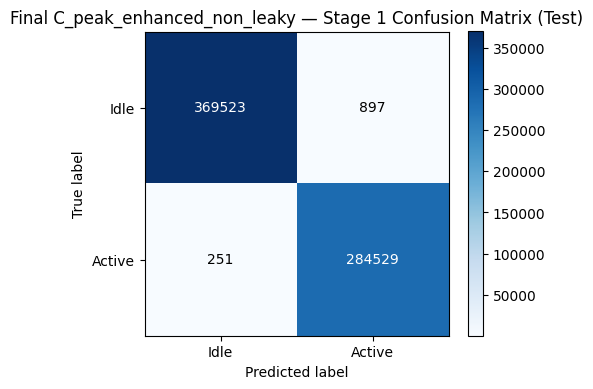


--- Stage 2 (Throughput Regressor) — FINAL TEST SET (FULL TRAINING) ---
  stage2_test_MAE_raw: 2.3495
  stage2_test_RMSE_raw: 5.5193
  stage2_test_R2_raw: 0.0081
  stage2_test_MAE_log: 0.4092
  stage2_test_RMSE_log: 0.6409
  stage2_test_R2_log: 0.1691


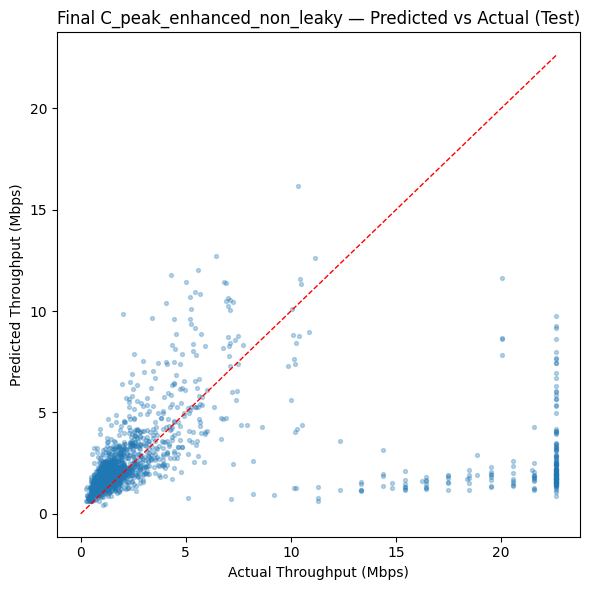

In [67]:
# 3. Pull Unseen Test Set Arrays
X_test_s1 = test_df[best_feats].astype(np.float32).values
y_test_s1 = test_df['Has_Throughput'].values.astype(np.int32)
X_test_s2 = test_pos[best_feats].astype(np.float32).values
y_test_s2_original = test_pos[target].values.astype(np.float32)
y_test_full = test_df[target].values.astype(np.float32)

# --- Stage 1 Test Report ---
test_s1_pred = predict_rf(final_stage1_model, stage1_backend, X_test_s1).astype(int)
print("\n--- Stage 1 (Active/Idle Classifier) — FINAL TEST SET (FULL TRAINING) ---")
print(classification_report(y_test_s1, test_s1_pred, target_names=['Idle', 'Active']))

# Plot Confusion Matrix
cm = confusion_matrix(y_test_s1, test_s1_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['Idle', 'Active'], yticklabels=['Idle', 'Active'],
       title=f'Final {best_exp_name} — Stage 1 Confusion Matrix (Test)', ylabel='True label', xlabel='Predicted label')
thresh = cm.max() / 2.
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# --- Stage 2 Test Report ---
test_s2_pred_log = predict_rf(final_stage2_model, stage2_backend, X_test_s2)
test_s2_pred = np.clip(np.expm1(test_s2_pred_log), 0, None)

stage2_test_metrics = eval_regression(y_test_s2_original, test_s2_pred, prefix="stage2_test_")
print("\n--- Stage 2 (Throughput Regressor) — FINAL TEST SET (FULL TRAINING) ---")
for k, v in stage2_test_metrics.items():
    print(f"  {k}: {v:.4f}")

# Scatter Plot Actual vs Predicted
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(y_test_s2_original), size=min(2000, len(y_test_s2_original)), replace=False)
plt.figure(figsize=(6, 6))
plt.scatter(y_test_s2_original[sample_idx], test_s2_pred[sample_idx], alpha=0.3, s=8)
max_val = max(y_test_s2_original[sample_idx].max(), test_s2_pred[sample_idx].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1)
plt.xlabel('Actual Throughput (Mbps)'); plt.ylabel('Predicted Throughput (Mbps)')
plt.title(f'Final {best_exp_name} — Predicted vs Actual (Test)')
plt.tight_layout()
plt.show()

In [68]:
# --- Combined Pipeline Full Test Report ---
test_final_pred = combine_stages(test_s1_pred, X_test_s1, len(test_df), final_stage2_model, stage2_backend)
final_test_metrics = eval_regression(y_test_full, test_final_pred, prefix="final_test_")

print(f"\n--- Combined Two-Stage Model — FULL TEST SET ({len(test_df):,} rows) ---")
for k, v in final_test_metrics.items():
    print(f"  {k}: {v:.4f}")

# Final Cleanup
del (
    final_stage1_model, final_stage2_model, 
    X_test_s1, y_test_s1, X_test_s2, y_test_s2_original, 
    y_test_full, test_s1_pred, test_s2_pred, test_final_pred
)
gc.collect()
print("\nProcess completely finished. Memory flushed cleanly.")


--- Combined Two-Stage Model — FULL TEST SET (655,200 rows) ---
  final_test_MAE_raw: 1.0238
  final_test_RMSE_raw: 3.6406
  final_test_R2_raw: 0.1826
  final_test_MAE_log: 0.1794
  final_test_RMSE_log: 0.4249
  final_test_R2_log: 0.6553

Process completely finished. Memory flushed cleanly.


In [71]:
# ============================================================
# HYBRID LSTM + MLP TWO-STAGE PIPELINE
# Stage 1: active vs idle classifier
# Stage 2: active-only log-throughput regressor
#
# IMPORTANT:
# - Test set is kept untouched until FINAL EVALUATION section.
# - Scaling is fit on train only.
# - Windows never cross User_ID boundary.
# - PRB / Resource_Efficiency / target columns are removed from features.
# ============================================================

import os
import time
import random
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 0. Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [72]:
# ============================================================
# 1. Basic configuration
# ============================================================

# Use real percentile target if you already reconstructed it.
TARGET = target
USER_COL = "User_ID"

TEST_ID_START = test_id_start
VAL_FRAC = 0.20

SEQ_LEN = 16       # 16 windows. If each row = 15 seconds, this is 4 minutes.
STRIDE = 4         # reduce overlap and memory
BATCH_SIZE = 256

LSTM_HIDDEN = 32
MLP_HIDDEN = 16
FUSION_HIDDEN = 32
NUM_LAYERS = 1
DROPOUT = 0.20

EPOCHS = 20
PATIENCE = 4
LR = 1e-3
WEIGHT_DECAY = 1e-5

# ============================================================
# 2. Prepare clean dataframe
# ============================================================
train_feats = best_feats
dynamic_trained_cols = [c for c in dynamic_cols if c in train_feats]
static_trained_cols = [c for c in static_cols if c in train_feats]
continous_static_cols = [c for c in static_trained_cols if not c.startswith('State_')]

assert(len(train_feats)==len(dynamic_trained_cols)+len(static_trained_cols))

print("dyn:", dynamic_trained_cols)
print("static:", static_trained_cols)

assert TARGET in df.columns, f"Target column {TARGET} not found."
assert USER_COL in df.columns, f"{USER_COL} not found."

# ============================================================
# 5. Fill missing values and scale features using TRAIN ONLY
# ============================================================
# Scale dynamic and static separately
dynamic_scaler = StandardScaler()
static_scaler = StandardScaler()

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df[dynamic_trained_cols] = dynamic_scaler.fit_transform(train_df[dynamic_trained_cols])
val_df[dynamic_trained_cols] = dynamic_scaler.transform(val_df[dynamic_trained_cols])
test_df[dynamic_trained_cols] = dynamic_scaler.transform(test_df[dynamic_trained_cols])

if continous_static_cols: 
    train_df[continous_static_cols] = static_scaler.fit_transform(train_df[continous_static_cols])
    val_df[continous_static_cols] = static_scaler.transform(val_df[continous_static_cols])
    test_df[continous_static_cols] = static_scaler.transform(test_df[continous_static_cols])
else:
    print("No continous static cols")

dyn: ['SINR_UL', 'BLER', 'SINR_UL_p90', 'BLER_p10', 'Log_Effective_Signal_Robust', 'RU_Current_Load', 'X_meters', 'Y_meters', 'Crowd_Density_5m']
static: ['State_0', 'State_1', 'State_2', 'State_3', 'State_4', 'State_5']
No continous static cols


In [73]:
# ============================================================
# 6. Dataset
# ============================================================

class HybridSequenceDataset(Dataset):
    """
    Returns:
      x_dynamic: shape (seq_len, dynamic_dim)
      x_static : shape (static_dim,) from last timestep
      y        : classifier label or log-throughput target
      y_raw    : raw throughput target
      end_idx  : end row index inside the provided dataframe
    """

    def __init__(
        self,
        df,
        dynamic_cols,
        static_cols,
        target_col,
        user_col,
        seq_len,
        stride,
        task="classifier",
        active_only=False,
        active_col="Has_Throughput",
    ):
        self.df = df.reset_index(drop=True)
        self.dynamic_cols = dynamic_cols
        self.static_cols = static_cols
        self.target_col = target_col
        self.user_col = user_col
        self.seq_len = seq_len
        self.stride = stride
        self.task = task
        self.active_only = active_only

        self.X_dyn = self.df[dynamic_cols].to_numpy(dtype=np.float32)
        self.X_sta = self.df[static_cols].to_numpy(dtype=np.float32)
        self.y_raw = self.df[target_col].to_numpy(dtype=np.float32)
        self.is_active = self.df[active_col].to_numpy(dtype=np.float32)
        self.uid = self.df[user_col].to_numpy()

        self.windows = self._build_windows()

    def _build_windows(self):
        windows = []
        n = len(self.df)

        i = 0
        while i + self.seq_len <= n:
            start = i
            end = i + self.seq_len - 1

            # Prevent sequence crossing users
            if self.uid[start] == self.uid[end]:
                if self.active_only and self.is_active[end] <= 0:
                    i += self.stride
                    continue

                windows.append((start, end))

            i += self.stride

        return windows

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        start, end = self.windows[idx]

        x_dyn = self.X_dyn[start:end + 1]
        x_sta = self.X_sta[end]
        y_value = self.y_raw[end]

        if self.task == "classifier":
            y = np.float32(self.is_active[end])
        elif self.task == "regressor":
            y = np.float32(np.log1p(y_value))
        else:
            raise ValueError("task must be 'classifier' or 'regressor'")

        return (
            torch.from_numpy(x_dyn),
            torch.from_numpy(x_sta),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(y_value, dtype=torch.float32),
            torch.tensor(end, dtype=torch.long),
        )


def make_loader(dataset, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(device.type == "cuda"),
    )


# ============================================================
# 7. Model
# ============================================================

class HybridLSTMMLP(nn.Module):
    def __init__(
        self,
        dynamic_dim,
        static_dim,
        lstm_hidden=32,
        mlp_hidden=16,
        fusion_hidden=32,
        num_layers=1,
        dropout=0.2,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=dynamic_dim,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.static_mlp = nn.Sequential(
            nn.Linear(static_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.head = nn.Sequential(
            nn.Linear(lstm_hidden + mlp_hidden, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1),
        )

    def forward(self, x_dynamic, x_static):
        lstm_out, _ = self.lstm(x_dynamic)
        lstm_last = lstm_out[:, -1, :]

        static_emb = self.static_mlp(x_static)

        x = torch.cat([lstm_last, static_emb], dim=1)
        return self.head(x).squeeze(-1)

In [74]:
# ============================================================
# 8. Train and predict helpers
# ============================================================

def train_model(model, train_loader, val_loader, criterion, epochs, lr, patience, weight_decay=0.0):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    best_state = None
    wait = 0

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0

        for x_dyn, x_sta, y, _, _ in train_loader:
            x_dyn = x_dyn.to(device)
            x_sta = x_sta.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            pred = model(x_dyn, x_sta)
            loss = criterion(pred, y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

            optimizer.step()
            train_loss_sum += loss.item() * x_dyn.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0

        with torch.no_grad():
            for x_dyn, x_sta, y, _, _ in val_loader:
                x_dyn = x_dyn.to(device)
                x_sta = x_sta.to(device)
                y = y.to(device)

                pred = model(x_dyn, x_sta)
                loss = criterion(pred, y)

                val_loss_sum += loss.item() * x_dyn.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
        })

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.5f} | val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1

            if wait >= patience:
                print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.5f}")
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def predict_model(model, loader):
    model.eval()

    preds = []
    ys = []
    y_raws = []
    end_indices = []

    with torch.no_grad():
        for x_dyn, x_sta, y, y_raw, end_idx in loader:
            x_dyn = x_dyn.to(device)
            x_sta = x_sta.to(device)

            pred = model(x_dyn, x_sta).detach().cpu().numpy()

            preds.append(pred)
            ys.append(y.numpy())
            y_raws.append(y_raw.numpy())
            end_indices.append(end_idx.numpy())

    return {
        "pred": np.concatenate(preds),
        "y": np.concatenate(ys),
        "y_raw": np.concatenate(y_raws),
        "end_idx": np.concatenate(end_indices),
    }


def best_threshold_by_f1(y_true, prob):
    thresholds = np.linspace(0.05, 0.95, 19)

    best_t = 0.5
    best_f1 = -1

    for t in thresholds:
        pred = (prob >= t).astype(int)
        score = f1_score(y_true, pred)

        if score > best_f1:
            best_f1 = score
            best_t = t

    return best_t, best_f1


def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, prob)

In [75]:
# ============================================================
# 9. Build TRAIN and VAL datasets only
#    Do not create/evaluate test loader yet.
# ============================================================

train_cls_ds = HybridSequenceDataset(
    train_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="classifier",
    active_only=False,
)

val_cls_ds = HybridSequenceDataset(
    val_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="classifier",
    active_only=False,
)

train_reg_ds = HybridSequenceDataset(
    train_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="regressor",
    active_only=True,
)

val_reg_ds = HybridSequenceDataset(
    val_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="regressor",
    active_only=True,
)

print("\nWindow counts:")
print(f"Classifier train: {len(train_cls_ds):,}")
print(f"Classifier val  : {len(val_cls_ds):,}")
print(f"Regressor train : {len(train_reg_ds):,}")
print(f"Regressor val   : {len(val_reg_ds):,}")


Window counts:
Classifier train: 521,280
Classifier val  : 130,320
Regressor train : 241,820
Regressor val   : 56,066


In [76]:
train_cls_loader = make_loader(train_cls_ds, shuffle=True)
val_cls_loader = make_loader(val_cls_ds, shuffle=False)

train_reg_loader = make_loader(train_reg_ds, shuffle=True)
val_reg_loader = make_loader(val_reg_ds, shuffle=False)
# ============================================================
# 10. Stage 1: Train classifier
# ============================================================

print("\n=== STAGE 1: Hybrid LSTM + MLP Classifier ===")

n_pos = sum(train_cls_ds.is_active[end] > 0 for _, end in train_cls_ds.windows)
n_neg = len(train_cls_ds) - n_pos

pos_weight = torch.tensor(n_neg / max(n_pos, 1), dtype=torch.float32).to(device)

print(f"Train active windows: {n_pos:,}")
print(f"Train idle windows  : {n_neg:,}")
print(f"pos_weight          : {pos_weight.item():.4f}")

stage1_model = HybridLSTMMLP(
    dynamic_dim=len(dynamic_trained_cols),
    static_dim=len(static_trained_cols),
    lstm_hidden=LSTM_HIDDEN,
    mlp_hidden=MLP_HIDDEN,
    fusion_hidden=FUSION_HIDDEN,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

criterion_cls = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

start = time.time()

stage1_model, stage1_history = train_model(
    model=stage1_model,
    train_loader=train_cls_loader,
    val_loader=val_cls_loader,
    criterion=criterion_cls,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY,
)

stage1_time = time.time() - start

# Validation-only threshold selection
val_cls_out = predict_model(stage1_model, val_cls_loader)

val_logits = val_cls_out["pred"]
val_prob = 1 / (1 + np.exp(-val_logits))
val_y_cls = val_cls_out["y"]

best_threshold, val_best_f1 = best_threshold_by_f1(val_y_cls, val_prob)
val_auc = safe_auc(val_y_cls, val_prob)

print("\nStage 1 validation:")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Val F1        : {val_best_f1:.4f}")
print(f"Val AUC       : {val_auc:.4f}")


=== STAGE 1: Hybrid LSTM + MLP Classifier ===
Train active windows: 241,820
Train idle windows  : 279,460
pos_weight          : 1.1557
Epoch 01 | train_loss=0.06041 | val_loss=0.03917
Epoch 02 | train_loss=0.03557 | val_loss=0.03881
Epoch 03 | train_loss=0.03513 | val_loss=0.03862
Epoch 04 | train_loss=0.03486 | val_loss=0.03846
Epoch 05 | train_loss=0.03471 | val_loss=0.03865
Epoch 06 | train_loss=0.03468 | val_loss=0.03854
Epoch 07 | train_loss=0.03464 | val_loss=0.03848
Epoch 08 | train_loss=0.03453 | val_loss=0.03829
Epoch 09 | train_loss=0.03458 | val_loss=0.03856
Epoch 10 | train_loss=0.03450 | val_loss=0.03842
Epoch 11 | train_loss=0.03443 | val_loss=0.03851
Epoch 12 | train_loss=0.03443 | val_loss=0.03842
Early stopping at epoch 12. Best val_loss=0.03829

Stage 1 validation:
Best threshold: 0.60
Val F1        : 0.9816
Val AUC       : 0.9991


In [77]:
# ============================================================
# 11. Stage 2: Train active-only log-throughput regressor
# ============================================================

print("\n=== STAGE 2: Hybrid LSTM + MLP Regressor ===")

stage2_model = HybridLSTMMLP(
    dynamic_dim=len(dynamic_trained_cols),
    static_dim=len(static_trained_cols),
    lstm_hidden=LSTM_HIDDEN,
    mlp_hidden=MLP_HIDDEN,
    fusion_hidden=FUSION_HIDDEN,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

criterion_reg = nn.MSELoss()

start = time.time()

stage2_model, stage2_history = train_model(
    model=stage2_model,
    train_loader=train_reg_loader,
    val_loader=val_reg_loader,
    criterion=criterion_reg,
    epochs=EPOCHS,
    lr=LR,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY,
)

stage2_time = time.time() - start

# Validation-only Stage 2 metrics
val_reg_out = predict_model(stage2_model, val_reg_loader)

val_pred_log = val_reg_out["pred"]
val_true_log = val_reg_out["y"]

val_pred_raw = np.clip(np.expm1(val_pred_log), 0, None)
val_true_raw = np.expm1(val_true_log)

val_stage2_mae = mean_absolute_error(val_true_raw, val_pred_raw)
val_stage2_rmse = np.sqrt(mean_squared_error(val_true_raw, val_pred_raw))
val_stage2_r2_raw = r2_score(val_true_raw, val_pred_raw)
val_stage2_r2_log = r2_score(val_true_log, val_pred_log)

print("\nStage 2 validation active-only:")
print(f"MAE raw : {val_stage2_mae:.4f}")
print(f"RMSE raw: {val_stage2_rmse:.4f}")
print(f"R2 raw  : {val_stage2_r2_raw:.4f}")
print(f"R2 log  : {val_stage2_r2_log:.4f}")


# ============================================================
# 12. Validation two-stage check
#     This is still validation, not test.
# ============================================================

val_all_reg_ds = HybridSequenceDataset(
    val_df,
    dynamic_trained_cols,
    static_trained_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="regressor",
    active_only=False,
)

val_all_reg_loader = make_loader(val_all_reg_ds, shuffle=False)

val_cls_out = predict_model(stage1_model, val_cls_loader)
val_reg_all_out = predict_model(stage2_model, val_all_reg_loader)

val_prob = 1 / (1 + np.exp(-val_cls_out["pred"]))
val_is_active = val_prob >= best_threshold

val_pred_raw_all = np.clip(np.expm1(val_reg_all_out["pred"]), 0, None)
val_final_pred = np.where(val_is_active, val_pred_raw_all, 0.0)

val_true_raw_all = val_cls_out["y_raw"]

val_final_mae = mean_absolute_error(val_true_raw_all, val_final_pred)
val_final_rmse = np.sqrt(mean_squared_error(val_true_raw_all, val_final_pred))
val_final_r2_raw = r2_score(val_true_raw_all, val_final_pred)
val_final_r2_log = r2_score(np.log1p(val_true_raw_all), np.log1p(val_final_pred))

print("\n=== VALIDATION TWO-STAGE RESULT ===")
print(f"Overall MAE raw : {val_final_mae:.4f}")
print(f"Overall RMSE raw: {val_final_rmse:.4f}")
print(f"Overall R2 raw  : {val_final_r2_raw:.4f}")
print(f"Overall R2 log  : {val_final_r2_log:.4f}")


=== STAGE 2: Hybrid LSTM + MLP Regressor ===
Epoch 01 | train_loss=0.42661 | val_loss=0.38928
Epoch 02 | train_loss=0.40103 | val_loss=0.38804
Epoch 03 | train_loss=0.39775 | val_loss=0.38563
Epoch 04 | train_loss=0.39525 | val_loss=0.38427
Epoch 05 | train_loss=0.39350 | val_loss=0.38394
Epoch 06 | train_loss=0.39251 | val_loss=0.38311
Epoch 07 | train_loss=0.39171 | val_loss=0.38338
Epoch 08 | train_loss=0.39097 | val_loss=0.38235
Epoch 09 | train_loss=0.39057 | val_loss=0.38261
Epoch 10 | train_loss=0.39016 | val_loss=0.38516
Epoch 11 | train_loss=0.38983 | val_loss=0.38304
Epoch 12 | train_loss=0.38976 | val_loss=0.38287
Early stopping at epoch 12. Best val_loss=0.38235

Stage 2 validation active-only:
MAE raw : 1.9774
RMSE raw: 5.2064
R2 raw  : 0.0242
R2 log  : 0.2160

=== VALIDATION TWO-STAGE RESULT ===
Overall MAE raw : 0.8698
Overall RMSE raw: 3.4436
Overall R2 raw  : 0.1554
Overall R2 log  : 0.5908


In [78]:
# ============================================================
# 13. FINAL TEST EVALUATION
#     Test is touched only here.
# ============================================================

print("\n\n==============================")
print("FINAL TEST EVALUATION")
print("==============================")

test_cls_ds = HybridSequenceDataset(
    test_df,
    dynamic_trained_cols,
    static_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="classifier",
    active_only=False,
)

test_reg_active_ds = HybridSequenceDataset(
    test_df,
    dynamic_trained_cols,
    static_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="regressor",
    active_only=True,
)

test_reg_all_ds = HybridSequenceDataset(
    test_df,
    dynamic_trained_cols,
    static_cols,
    TARGET,
    USER_COL,
    SEQ_LEN,
    STRIDE,
    task="regressor",
    active_only=False,
)

test_cls_loader = make_loader(test_cls_ds, shuffle=False)
test_reg_active_loader = make_loader(test_reg_active_ds, shuffle=False)
test_reg_all_loader = make_loader(test_reg_all_ds, shuffle=False)

print(f"Test classifier windows : {len(test_cls_ds):,}")
print(f"Test active reg windows : {len(test_reg_active_ds):,}")
print(f"Test all reg windows    : {len(test_reg_all_ds):,}")



FINAL TEST EVALUATION
Test classifier windows : 162,900
Test active reg windows : 70,742
Test all reg windows    : 162,900


In [79]:
# ----------------------------
# Stage 1 test
# ----------------------------

test_cls_out = predict_model(stage1_model, test_cls_loader)

test_logits = test_cls_out["pred"]
test_prob = 1 / (1 + np.exp(-test_logits))
test_y_cls = test_cls_out["y"]

test_cls_pred = (test_prob >= best_threshold).astype(int)

test_stage1_f1 = f1_score(test_y_cls, test_cls_pred)
test_stage1_auc = safe_auc(test_y_cls, test_prob)

print("\nStage 1 TEST:")
print(f"F1 : {test_stage1_f1:.4f}")
print(f"AUC: {test_stage1_auc:.4f}")


# ----------------------------
# Stage 2 active-only test
# ----------------------------

test_reg_active_out = predict_model(stage2_model, test_reg_active_loader)

test_pred_log_active = test_reg_active_out["pred"]
test_true_log_active = test_reg_active_out["y"]

test_pred_raw_active = np.clip(np.expm1(test_pred_log_active), 0, None)
test_true_raw_active = np.expm1(test_true_log_active)

test_stage2_mae = mean_absolute_error(test_true_raw_active, test_pred_raw_active)
test_stage2_rmse = np.sqrt(mean_squared_error(test_true_raw_active, test_pred_raw_active))
test_stage2_r2_raw = r2_score(test_true_raw_active, test_pred_raw_active)
test_stage2_r2_log = r2_score(test_true_log_active, test_pred_log_active)

print("\nStage 2 TEST active-only:")
print(f"MAE raw : {test_stage2_mae:.4f}")
print(f"RMSE raw: {test_stage2_rmse:.4f}")
print(f"R2 raw  : {test_stage2_r2_raw:.4f}")
print(f"R2 log  : {test_stage2_r2_log:.4f}")


# ----------------------------
# Final two-stage test
# ----------------------------

test_reg_all_out = predict_model(stage2_model, test_reg_all_loader)

# These should align because both datasets use active_only=False
assert len(test_cls_out["pred"]) == len(test_reg_all_out["pred"])

test_is_active = test_prob >= best_threshold

test_pred_raw_all = np.clip(np.expm1(test_reg_all_out["pred"]), 0, None)
test_final_pred = np.where(test_is_active, test_pred_raw_all, 0.0)

test_true_raw_all = test_cls_out["y_raw"]

test_final_mae = mean_absolute_error(test_true_raw_all, test_final_pred)
test_final_rmse = np.sqrt(mean_squared_error(test_true_raw_all, test_final_pred))
test_final_r2_raw = r2_score(test_true_raw_all, test_final_pred)
test_final_r2_log = r2_score(np.log1p(test_true_raw_all), np.log1p(test_final_pred))

print("\n=== FINAL TWO-STAGE TEST RESULT ===")
print(f"Overall MAE raw : {test_final_mae:.4f}")
print(f"Overall RMSE raw: {test_final_rmse:.4f}")
print(f"Overall R2 raw  : {test_final_r2_raw:.4f}")
print(f"Overall R2 log  : {test_final_r2_log:.4f}")


Stage 1 TEST:
F1 : 0.9975
AUC: 1.0000

Stage 2 TEST active-only:
MAE raw : 2.1488
RMSE raw: 5.3434
R2 raw  : 0.0246
R2 log  : 0.2150

=== FINAL TWO-STAGE TEST RESULT ===
Overall MAE raw : 0.9364
Overall RMSE raw: 3.5233
Overall R2 raw  : 0.1936
Overall R2 log  : 0.6735


In [80]:
# ============================================================
# 14. Summary table
# ============================================================

hybrid_summary = pd.DataFrame([{
    "Model": "Hybrid LSTM + MLP",
    "Target": TARGET,
    "Seq_Len": SEQ_LEN,
    "Stride": STRIDE,
    "Dynamic_Features": len(dynamic_trained_cols),
    "Static_Features": len(static_trained_cols),

    "Val_Stage1_F1": val_best_f1,
    "Val_Stage1_AUC": val_auc,
    "Val_Stage2_R2_Log": val_stage2_r2_log,
    "Val_Final_R2_Log": val_final_r2_log,
    "Val_Final_RMSE_Raw": val_final_rmse,

    "Test_Stage1_F1": test_stage1_f1,
    "Test_Stage1_AUC": test_stage1_auc,
    "Test_Stage2_MAE_Raw": test_stage2_mae,
    "Test_Stage2_RMSE_Raw": test_stage2_rmse,
    "Test_Stage2_R2_Raw": test_stage2_r2_raw,
    "Test_Stage2_R2_Log": test_stage2_r2_log,
    "Test_Final_MAE_Raw": test_final_mae,
    "Test_Final_RMSE_Raw": test_final_rmse,
    "Test_Final_R2_Raw": test_final_r2_raw,
    "Test_Final_R2_Log": test_final_r2_log,

    "Stage1_Time_s": stage1_time,
    "Stage2_Time_s": stage2_time,
    "Total_Time_s": stage1_time + stage2_time,
}])

print("\nSummary:")
print(hybrid_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Summary:
            Model         Target  Seq_Len  Stride  Dynamic_Features  Static_Features  Val_Stage1_F1  Val_Stage1_AUC  Val_Stage2_R2_Log  Val_Final_R2_Log  Val_Final_RMSE_Raw  Test_Stage1_F1  Test_Stage1_AUC  Test_Stage2_MAE_Raw  Test_Stage2_RMSE_Raw  Test_Stage2_R2_Raw  Test_Stage2_R2_Log  Test_Final_MAE_Raw  Test_Final_RMSE_Raw  Test_Final_R2_Raw  Test_Final_R2_Log  Stage1_Time_s  Stage2_Time_s  Total_Time_s
Hybrid LSTM + MLP Throughput_p95       16       4                 9                6         0.9816          0.9991             0.2160            0.5908              3.4436          0.9975           1.0000               2.1488                5.3434              0.0246              0.2150              0.9364               3.5233             0.1936             0.6735       256.6765       127.5615      384.2380


In [13]:
# # to download file from /kaggle/working
# from IPython.display import FileLink
# FileLink(r'master_quantile_qfull_df.parquet')

/kaggle/working/master_quantile_qfull_df.parquet

### **3.1: Random Forest Regressor**

### **3.2: Artificial Neural Network**

## **4: Vertical Federated Learning Pipeline**

In this section, we simulate a privacy-preserving VFL environment by splitting the feature space (e.g., User Equipment features vs. Radio Unit features) across distinct local clients before aggregating.

### **4.1: VFL Architecture & Feature Split Setup**

### **4.2: VFL Model Build & Training**

## **5: Cross-Validation & Evaluation**

Here we rigorously test all models using K-Fold Cross Validation and evaluate them using standard regression metrics (RMSE, MAE, R²).

### **5.1: Baseline Models Evaluation (RF vs. ANN)**


### **5.2: VFL vs. Centralized Performance Comparison**


## **6: Full Pipeline & Final Exports**

Consolidating the best-performing models, generating the final comparison plots, and exporting predictions to support the final project report and checkpoint with the Professor.



### **6.1: Feature Importance & Interpretability**

### **6.2: Final Prediction Pipeline**